In [2]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import json
import sire

def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')

result = json.loads(open("D:/code/sire/demo/demo_paper/sire/dog/simulation_result.json").read())
with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  pltResult = result
  timeIndices = pltResult['timeIndex']
  contactInfo = pltResult["contactInfo"]
  partpq = pltResult["partPq"]
  partvs = pltResult["partVs"]
  partas = pltResult["partAs"]
  singleComponentForces = pltResult["singleComponentForces"]
  generalForces = pltResult["generalForces"]
  dts = pltResult["dts"]
  x = []
  y = []
  yv = []
  
  lowerBound = sire.binarySearch(timeIndices, 3.132)
  upperBound = sire.binarySearch(timeIndices, 3.134)
  
  for j in range(lowerBound, upperBound + 1):
    print(f"Time: {timeIndices[j]:.3f}s, dt: {dts[j]:.4f}s")
    print(f"part pq: {partpq[j][4]}")
    print(f"part vs: {partvs[j][4]}")
    print(f"part as: {partas[j][4]}")
    # print(f"part pq: {partpq[j]}")
    # print(f"part vs: {partvs[j]}")
    # print(f"part as: {partas[j]}")
    print(f"single component forces: {singleComponentForces[j]}")
    print(f"general forces: {generalForces[j][4]}")
    # print(j, timeIndices[j], dts[j], partpq[j][4], partvs[j][4], partas[j][4], contactInfo[j])
    # x.append(timeIndices[j])
    # y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
    # yv.append(partvs[j][1][2])  # z velocity
  # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
  # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
  # plt.plot(x, y, linewidth=1, label=f"k:", color=scientific_colors[0], linestyle=linestyles[0 % 4])
  
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # # plt.ylim(top=5.5, bottom=-0.5)
  # plt.ylabel(r'Height (m)')
  # plt.xlabel(r'Time (s)')
  # # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  # plt.show()

Time: 3.132s, dt: 0.0020s
part pq: [-0.851298349872833, 1.6471395388775874, 0.07506248138302964, 0.2019451321115632, -0.2584924043261871, 0.8941737698385236, 0.3047180825859748]
part vs: [-15.203438182055779, -9.798899625089287, 48.27068319864425, -18.617305631125348, -19.62708305578562, -9.547246291871575]
part as: [-3992.8784462270864, -2764.919503459753, 12166.54635879153, -5048.32989660168, -4127.868748199059, -2561.7120273848145]
single component forces: [1.2087020238495558, -10.9792838829913, -5.110493830528687, -2.309569489976492, 1.2254047085540483, -0.5440301899039208, 2.9320038219611746, -1.233695037979028, -0.8592620475323588, 0.7348811730914323, -0.6760869734158224, -0.25929033240477084]
general forces: [-91.81752714461719, 78.78674543508302, 201.64469265410804, 293.3402882056578, 134.88674112763482, 80.86745217298285]
Time: 3.134s, dt: 0.0020s
part pq: [-0.8536116999708921, 1.6458840554315821, 0.07815486487457107, 0.16430330150257744, -0.24400495633640382, 0.90197095646750

In [3]:
currentIdx = sire.binarySearch(timeIndices, 3.132)
# upperBound = sire.binarySearch(timeIndices, 3.132)

# for j in range(lowerBound, upperBound + 1):
print(f"Time: {timeIndices[currentIdx]:.3f}s, dt: {dts[currentIdx]:.4f}s")
print(f"part pq: {partpq[currentIdx][4]}")
print(f"part vs: {partvs[currentIdx][4]}")
print(f"part as: {partas[currentIdx][4]}")
print(f"single component forces: {singleComponentForces[currentIdx]}")
print(f"general forces: {generalForces[currentIdx][4]}")
p = [-0.893203, 1.77094, -0.107569]
p2 = [-0.882395, 1.76078, -0.110441]
print(sire.as2ap(partvs[currentIdx][4], partas[currentIdx][4], p))
print(sire.as2ap(partvs[currentIdx][4], partas[currentIdx][4], p2))
print(sire.vs2vp(partvs[currentIdx][4], p))
currentPq = np.array(partpq[currentIdx][4])
currentVs = np.array(partvs[currentIdx][4])
currentAs = np.array(partas[currentIdx][4])
currentAp = np.array(sire.as2ap(currentVs, currentAs, p))
currentVp = np.array(sire.vs2vp(currentVs, p))
newVs = currentAs * 0.002 + currentVs
newVp = currentAp * 0.002 + currentVp
print(sire.vs2vp(newVs, p))
print(newVp)


Time: 3.132s, dt: 0.0020s
part pq: [-0.851298349872833, 1.6471395388775874, 0.07506248138302964, 0.2019451321115632, -0.2584924043261871, 0.8941737698385236, 0.3047180825859748]
part vs: [-15.203438182055779, -9.798899625089287, 48.27068319864425, -18.617305631125348, -19.62708305578562, -9.547246291871575]
part as: [-3992.8784462270864, -2764.919503459753, 12166.54635879153, -5048.32989660168, -4127.868748199059, -2561.7120273848145]
single component forces: [1.2087020238495558, -10.9792838829913, -5.110493830528687, -2.309569489976492, 1.2254047085540483, -0.5440301899039208, 2.9320038219611746, -1.233695037979028, -0.8592620475323588, 0.7348811730914323, -0.6760869734158224, -0.25929033240477084]
general forces: [-91.81752714461719, 78.78674543508302, 201.64469265410804, 293.3402882056578, 134.88674112763482, 80.86745217298285]
[1000.3102764480268, -1097.7856279584082, -324.9305319179439]
[976.7669101072511, -1132.112723139481, -226.9064594692063]
[3.815427863299073, -3.273915544885

In [8]:
currentIdx = sire.binarySearch(timeIndices, 3.135)
# upperBound = sire.binarySearch(timeIndices, 3.132)

# for j in range(lowerBound, upperBound + 1):
print(f"Time: {timeIndices[currentIdx]:.3f}s, dt: {dts[currentIdx]:.4f}s")
print(f"part pq: {partpq[currentIdx][4]}")
print(f"part vs: {partvs[currentIdx][4]}")
print(f"part as: {partas[currentIdx][4]}")
print(f"single component forces: {singleComponentForces[currentIdx]}")
print(f"general forces: {generalForces[currentIdx][4]}")

Time: 3.136s, dt: 0.0020s
part pq: [-0.8561648855653258, 1.6442195799001538, 0.08224658210076594, 0.11724601477066007, -0.22505369176988285, 0.9094112325942904, 0.3295078418983044]
part vs: [-28.07148951871041, -19.200705096058552, 90.80995034687437, -36.05097316384753, -34.42953744051378, -18.012674395780344]
part as: [-149.73179505973397, -268.84134259559204, 1529.2237127828791, -574.1237445858451, -650.792284033857, -171.50207241722086]
single component forces: [0.25291303462919335, -14.33175821595726, -17.802691106737953, -1.7439113567857873, 0.9179658060255143, -0.5222893477663644, 3.3538312567741784, -1.5045818229932577, -0.8287160244557992, 1.187611445177063, -0.6105914739790985, -0.5664493243765127]
general forces: [-46.32104740063854, 48.53200741511274, 111.8157608652232, 163.28623122084568, 74.53356755990887, 35.29310691286898]


In [ ]:
import sire
import json
import numpy as np
cs = sire.ControlServer.instance()
sire.fromXmlFile(cs, r'D:\code\sire\demo\demo_paper\sire\dog\test_dog.xml')
cs.init()
simulator = sire.simulationLoop(cs)
model = cs.model()
result = json.loads(open("D:/code/sire/demo/demo_paper/sire/dog/simulation_result.json").read())
pltResult = result
timeIndices = pltResult['timeIndex']
contactInfo = pltResult["contactInfo"]
partpq = pltResult["partPq"]
partvs = pltResult["partVs"]
partas = pltResult["partAs"]
singleComponentForces = pltResult["singleComponentForces"]
generalForces = pltResult["generalForces"]
currentIdx = sire.binarySearch(timeIndices, 3.132)
R = np.array([0, -1, 0, 1, 0, 0, 0, 0, 1])
cp = np.array([-0.893203, 1.77094, -0.107569])
nowPq = partpq[currentIdx]
nowVs = partvs[currentIdx]
nowGf = generalForces[currentIdx]
nowMf = singleComponentForces[currentIdx]
cf = [78.7867, 91.8175, 201.645]
pm = np.block([[R.reshape(3, 3), cp.reshape(3, 1)], [0, 0, 0, 1]])
print(pm)
print(pm.flatten())
print(nowGf[4], sire.fpm2fs(cf, pm.flatten()))
nowGf[4] = sire.fpm2fs(cf, pm.flatten())
model.setPartPq(nowPq)
model.setPartVs(nowVs)
model.setGeneralForce(nowGf)
model.setMotorForce(nowMf)
model.forwardDynamics()
print(model.getPartAs()[4])

currentAp = np.array(sire.as2ap(nowVs[4], model.getPartAs()[4], cp))
print(currentAp)

[[ 0.       -1.        0.       -0.893203]
 [ 1.        0.        0.        1.77094 ]
 [ 0.        0.        1.       -0.107569]
 [ 0.        0.        0.        1.      ]]
[ 0.       -1.        0.       -0.893203  1.        0.        0.
  1.77094   0.        0.        1.       -0.107569  0.        0.
  0.        1.      ]
[-91.81752714461719, 78.78674543508302, 201.64469265410804, 293.3402882056578, 134.88674112763482, 80.86745217298285] [-91.8175, 78.7867, 201.645, 365.57620283230005, 189.9866355925, 92.2307666499]
[-3992.878446226971, -2764.919503459686, 12166.546358791265, -5048.329896601583, -4127.868748198904, -2561.7120273847677, 0.0]
[ 1000.31027645 -1097.78562796  -324.93053192]


902 907
902 907
902 907
902 908
902 908


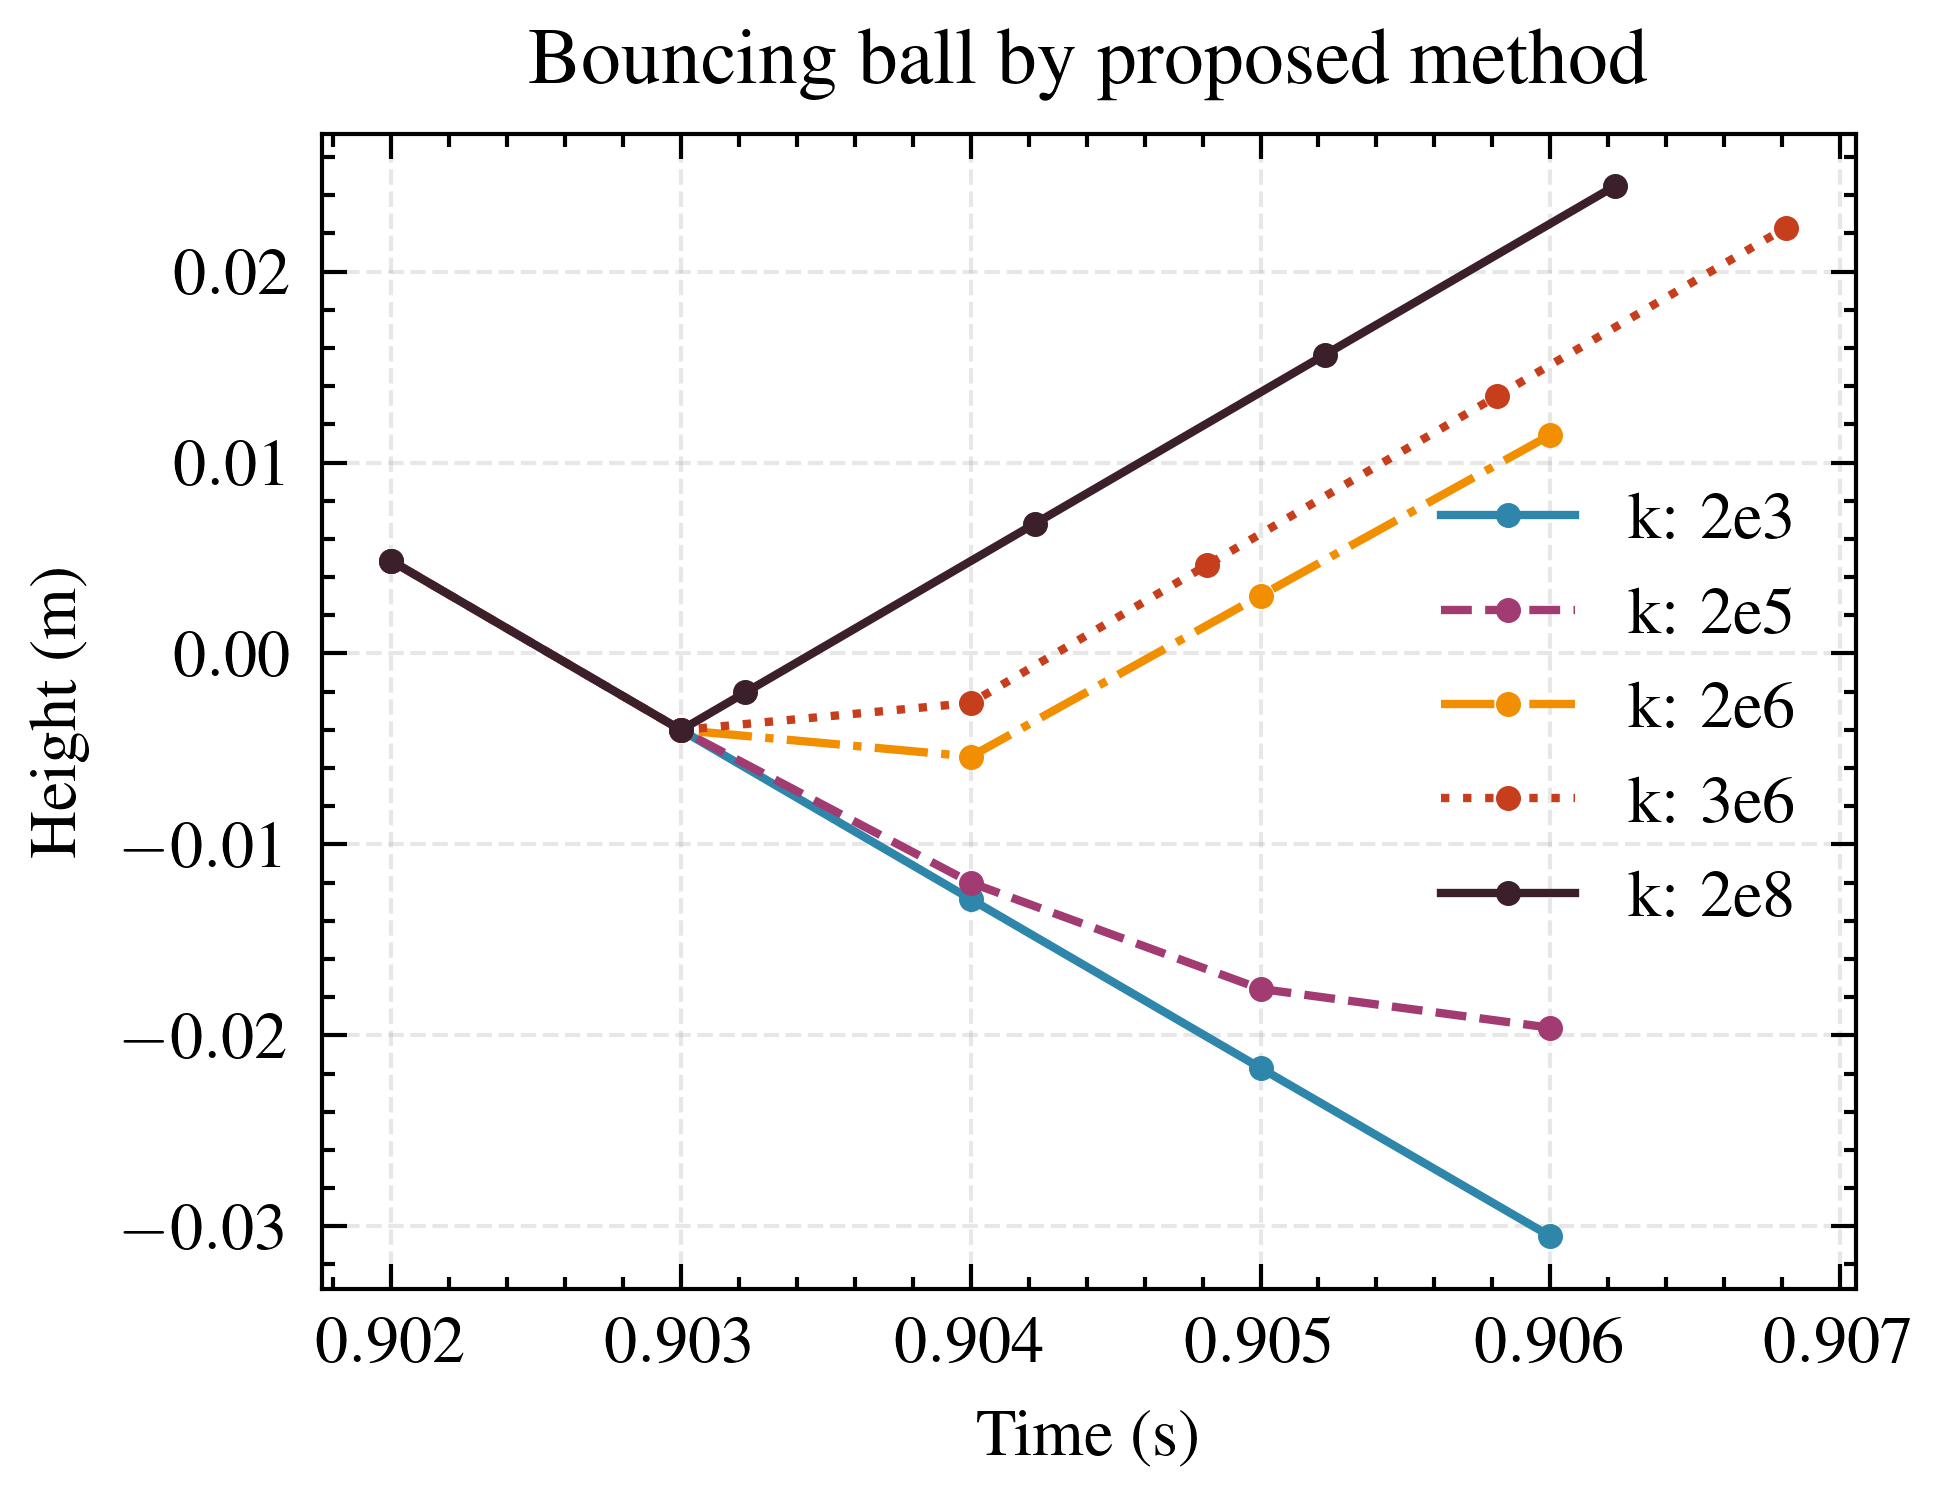

In [16]:
with plt.style.context(['science','ieee']):
  legendStrs = []
  linestyles = ["-","--", "-.", ":"]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0.902)
    upperBound = sire.binarySearch(timeIndices, 0.906)
    print(lowerBound, upperBound + 1)
    
    for j in range(lowerBound, upperBound + 1):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)')
  plt.xlabel(r'Time (s)')
  plt.title('Bouncing ball by proposed method')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [11]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e8, 0], [2e8, 2e3], [2e8, 5e3], [2e8, 1e4], [2e8, 1e5]]
sim_duration = 4
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
  print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  contact_solver_result = simulator.recordsContactCptInfo()
  result.append([displayInitJson, sim_result, contact_solver_result])


{k:200000000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000000.0,d:2000.0,cof:0,threshold_velocity:1e-4}
{k:200000000.0,d:5000.0,cof:0,threshold_velocity:1e-4}
{k:200000000.0,d:10000.0,cof:0,threshold_velocity:1e-4}
{k:200000000.0,d:100000.0,cof:0,threshold_velocity:1e-4}


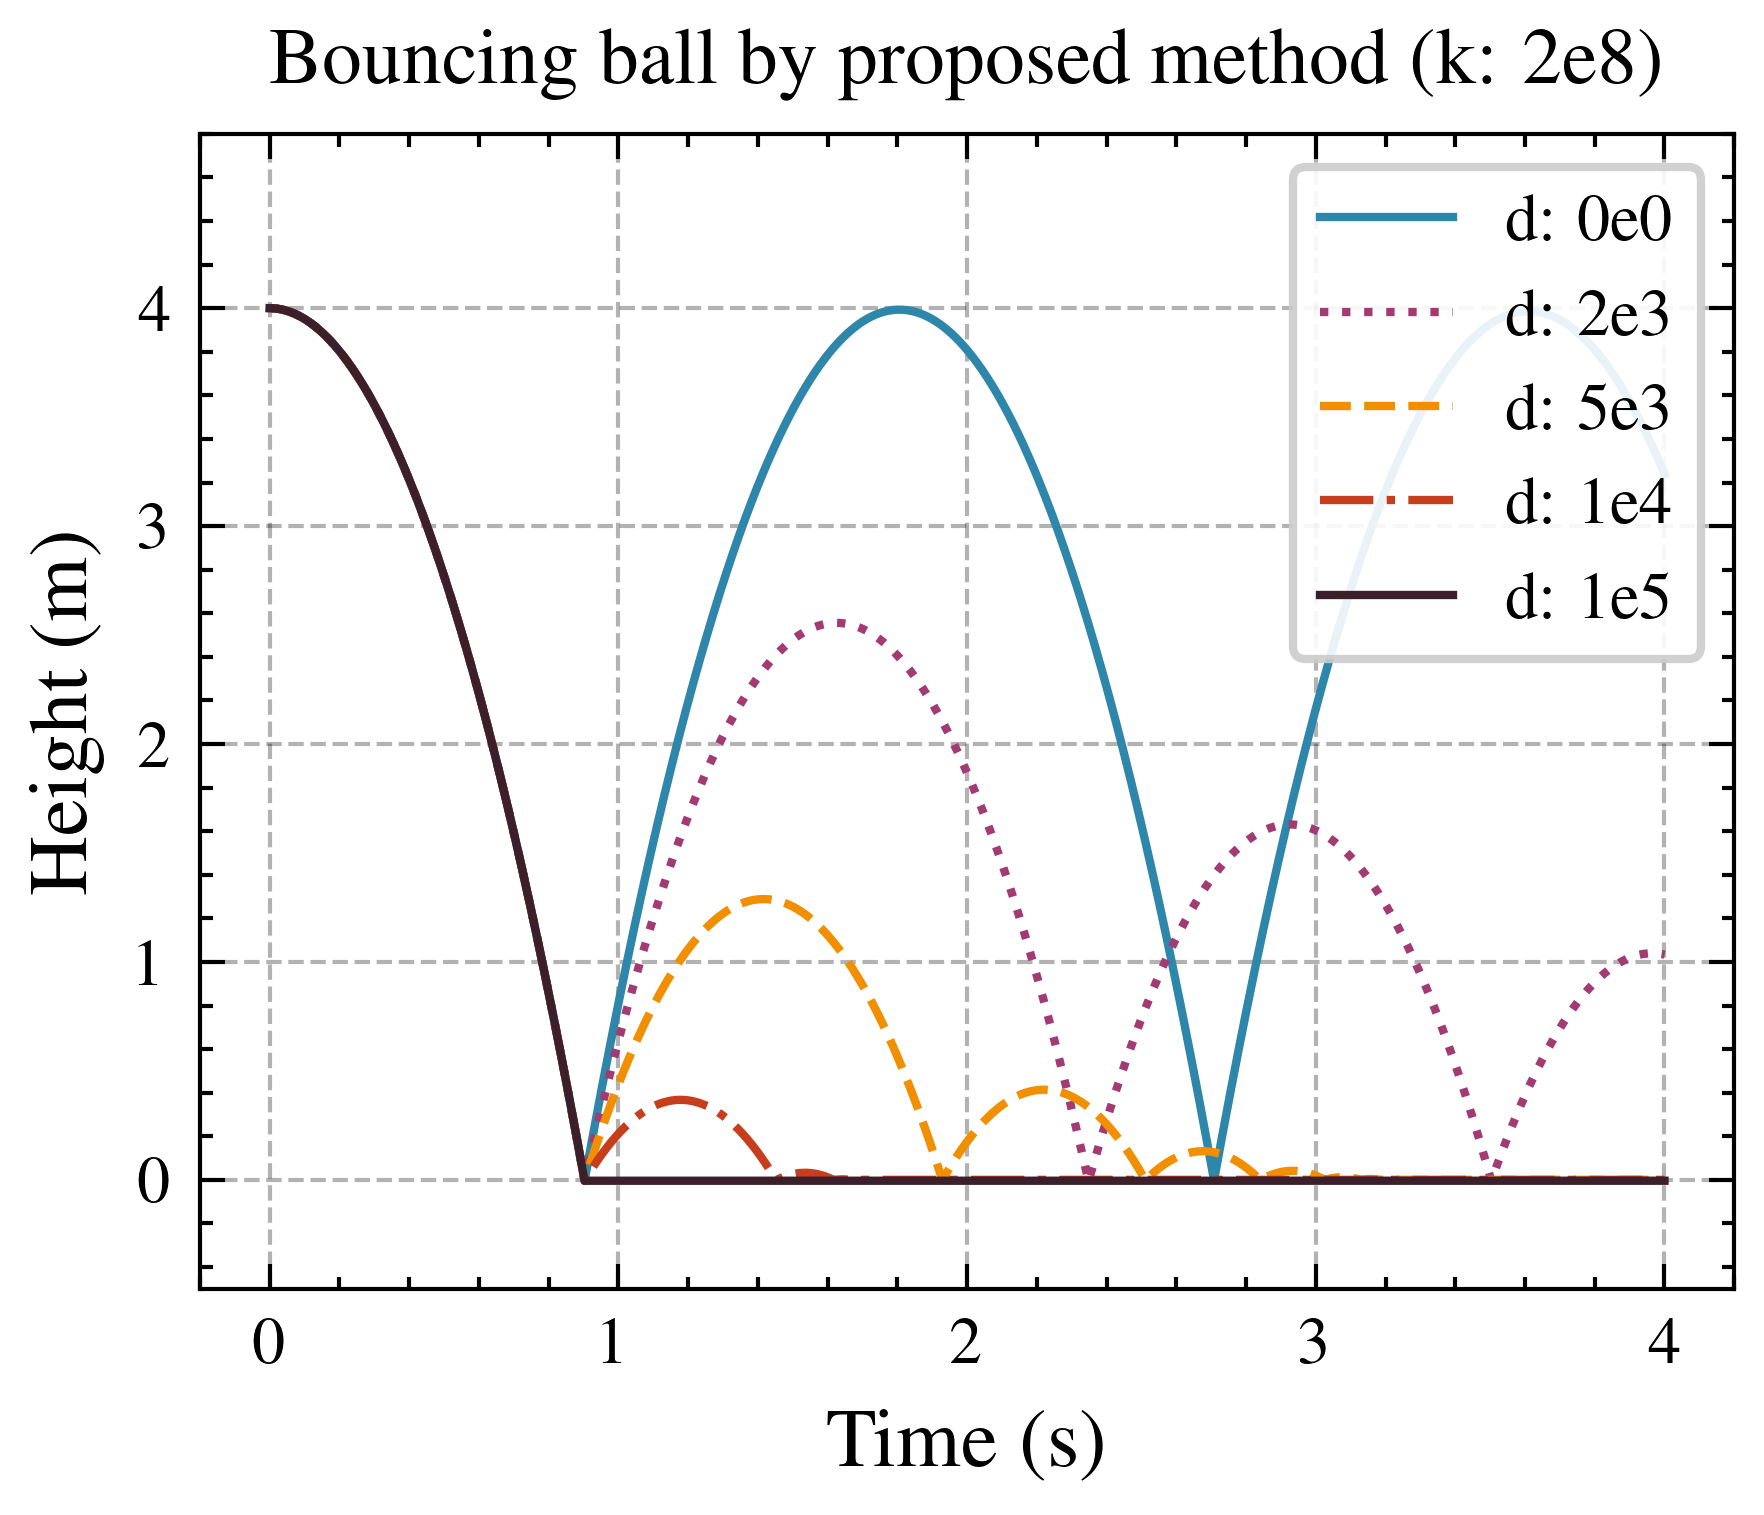

In [12]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0)
    upperBound = sire.binarySearch(timeIndices, 10)
    
    for j in range(lowerBound, upperBound + 1):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, linewidth=1, label=f"d: {simple_sci_format(parameters[i][1])}", color=scientific_colors[i], linestyle=linestyles[i % 4])
  
  # plt.legend(loc="best", fontsize=8)
  plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  plt.ylim(top=4.8, bottom=-0.5)
  plt.title('Bouncing ball by proposed method (k: 2e8)')
  plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

  plt.close()
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0)
    upperBound = sire.binarySearch(timeIndices, 10)
    
    for j in range(lowerBound, upperBound + 1):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, linewidth=1, label=f"d: {simple_sci_format(parameters[i][1])}", color=scientific_colors[i], linestyle=linestyles[i % 4])
  
  # plt.legend(loc="best", fontsize=8)
  plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  plt.ylim(top=4.8, bottom=-0.5)
  # plt.title('Bouncing ball by proposed method (k: 2e8)')
  plt.grid(True, alpha=0.3)
  plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire_hard.pdf", format="pdf")
  # plt.show()
  plt.close()

{'currentTime': [0.9030000000000007, 2.708222155220917], 'minTime': [0.0002221552211042472, 0.00022215523338174858], 'modifiedContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.858429999999922}], [{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.848619999998245}]], 'realContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.858429999999922}], [{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.848619999998245}]]}
902 908
902 0.9020000000000007 0.0010000000000000009 [0.0, 0.0, 0.5048480700000217, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -8.848619999999922, 0.0, 0.0, 0.0] [0.0, 0.0, -9.81, -0.0, -0.0, -0.0] None
903 0.9030000000000007 0.0010000000000000009 [0.0, 0.0, 0.4959896400000218, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -8.858429999999922, 0.0, 0.0, 0.0] [0.0, 0.0, 79749.91500058482, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 79759.72500058482], 'contactForceVel': [0.0, 0.0, 0.0], 'contactWrench': [-0.0, 0.0, 79759.725000584

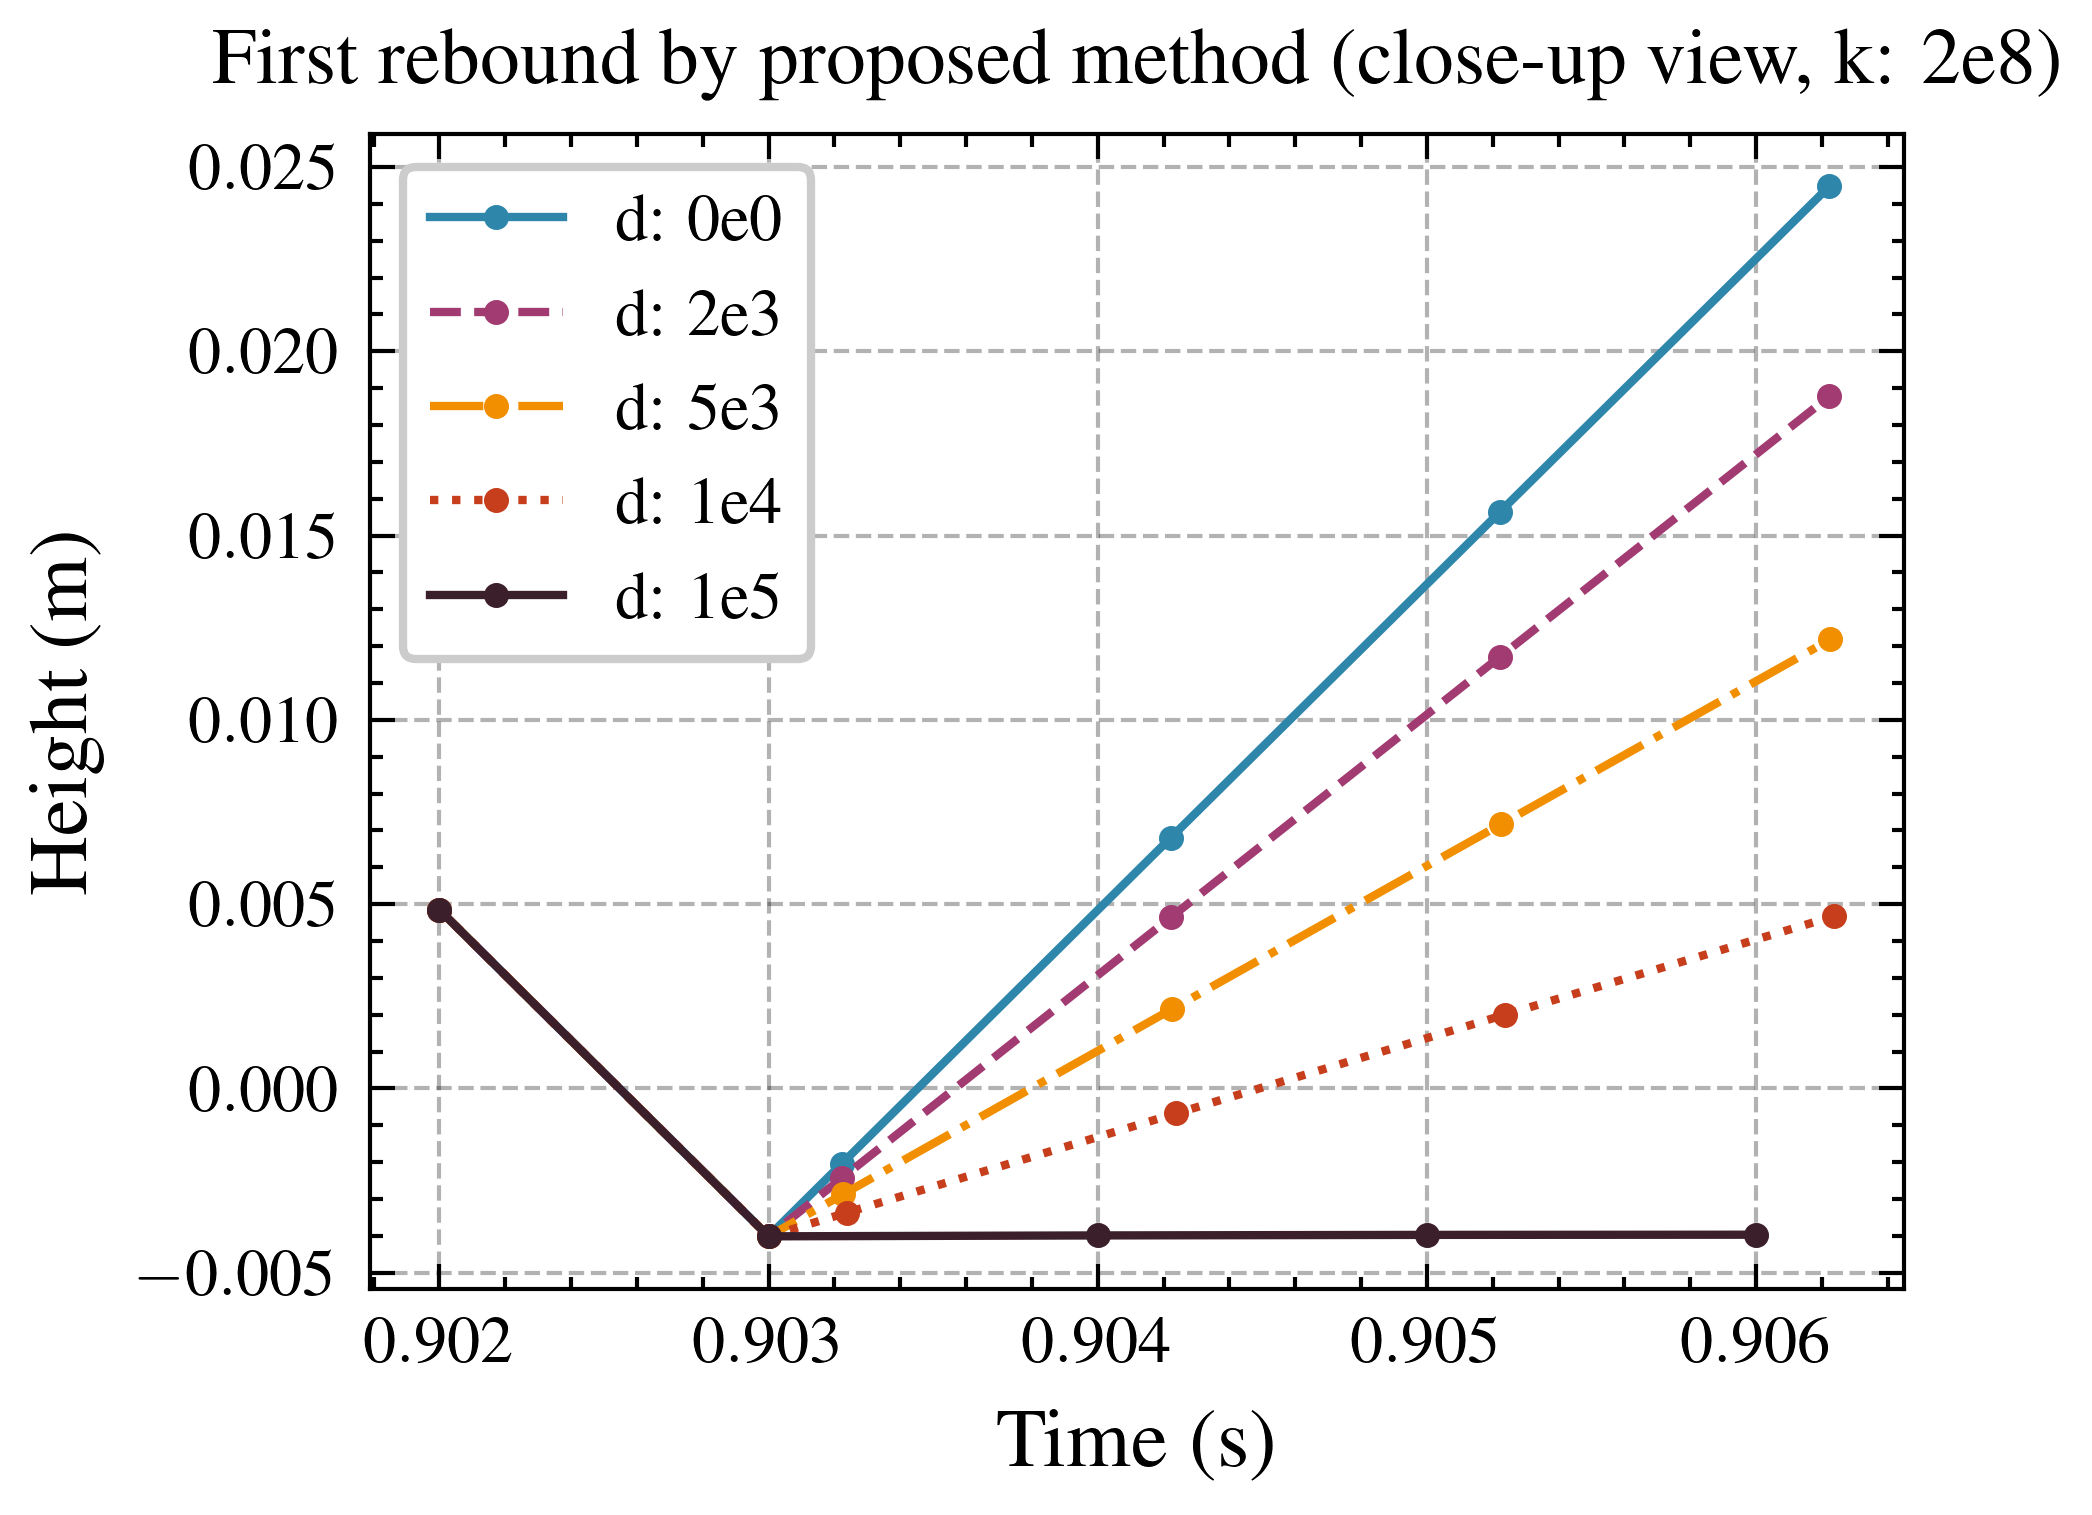

{'currentTime': [0.9030000000000007, 2.708222155220917], 'minTime': [0.0002221552211042472, 0.00022215523338174858], 'modifiedContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.858429999999922}], [{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.848619999998245}]], 'realContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.858429999999922}], [{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.848619999998245}]]}
902 908
902 0.9020000000000007 0.0010000000000000009 [0.0, 0.0, 0.5048480700000217, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -8.848619999999922, 0.0, 0.0, 0.0] [0.0, 0.0, -9.81, -0.0, -0.0, -0.0] None
903 0.9030000000000007 0.0010000000000000009 [0.0, 0.0, 0.4959896400000218, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -8.858429999999922, 0.0, 0.0, 0.0] [0.0, 0.0, 79749.91500058482, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 79759.72500058482], 'contactForceVel': [0.0, 0.0, 0.0], 'contactWrench': [-0.0, 0.0, 79759.725000584

In [13]:
with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-","--", "-.", ":"]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    print(result[i][2])
    
    lowerBound = sire.binarySearch(timeIndices, 0.902)
    upperBound = sire.binarySearch(timeIndices, 0.906)
    print(lowerBound, upperBound + 1)
    
    for j in range(lowerBound, upperBound + 1):
      print(j, timeIndices[j], dts[j], partpq[j][1], partvs[j][1], partas[j][1], contactInfo[j])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"d: {simple_sci_format(parameters[i][1])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  plt.title('First rebound by proposed method (close-up view, k: 2e8)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()
  plt.close()
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    print(result[i][2])
    
    lowerBound = sire.binarySearch(timeIndices, 0.902)
    upperBound = sire.binarySearch(timeIndices, 0.906)
    print(lowerBound, upperBound + 1)
    
    for j in range(lowerBound, upperBound + 1):
      print(j, timeIndices[j], dts[j], partpq[j][1], partvs[j][1], partas[j][1], contactInfo[j])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"d: {simple_sci_format(parameters[i][1])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  # plt.title('First rebound by proposed method (close-up view, k: 2e8)')
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire_hard_zoomed.pdf", format="pdf")
  plt.close()

{'currentTime': [0.9030000000000007, 0.9040000000000007, 0.9050000000000007, 0.9060000000000007, 0.9070000000000007, 0.9080000000000007, 0.9090000000000007, 0.9100000000000007, 0.9110000000000007, 0.9120000000000007, 0.9130000000000007, 0.9140000000000007, 0.9150000000000007, 0.9160000000000007, 0.9170000000000007, 0.9180000000000007, 0.9190000000000007, 0.9200000000000007, 0.9210000000000007, 0.9220000000000007, 0.9230000000000007, 0.9240000000000007, 0.9250000000000007, 0.9260000000000007, 0.9270000000000007, 0.9280000000000007, 0.9290000000000007, 0.9300000000000007, 0.9310000000000007, 0.9320000000000007, 0.9330000000000007, 0.9340000000000007, 0.9350000000000007, 0.9360000000000007, 0.9370000000000007, 0.9380000000000007, 0.9390000000000007, 0.9400000000000007, 0.9410000000000007, 0.9420000000000007, 0.9430000000000007, 0.9440000000000007, 0.9450000000000007, 0.9460000000000007, 0.9470000000000007, 0.9480000000000007, 0.9490000000000007, 0.9500000000000007, 0.9510000000000007, 0.9

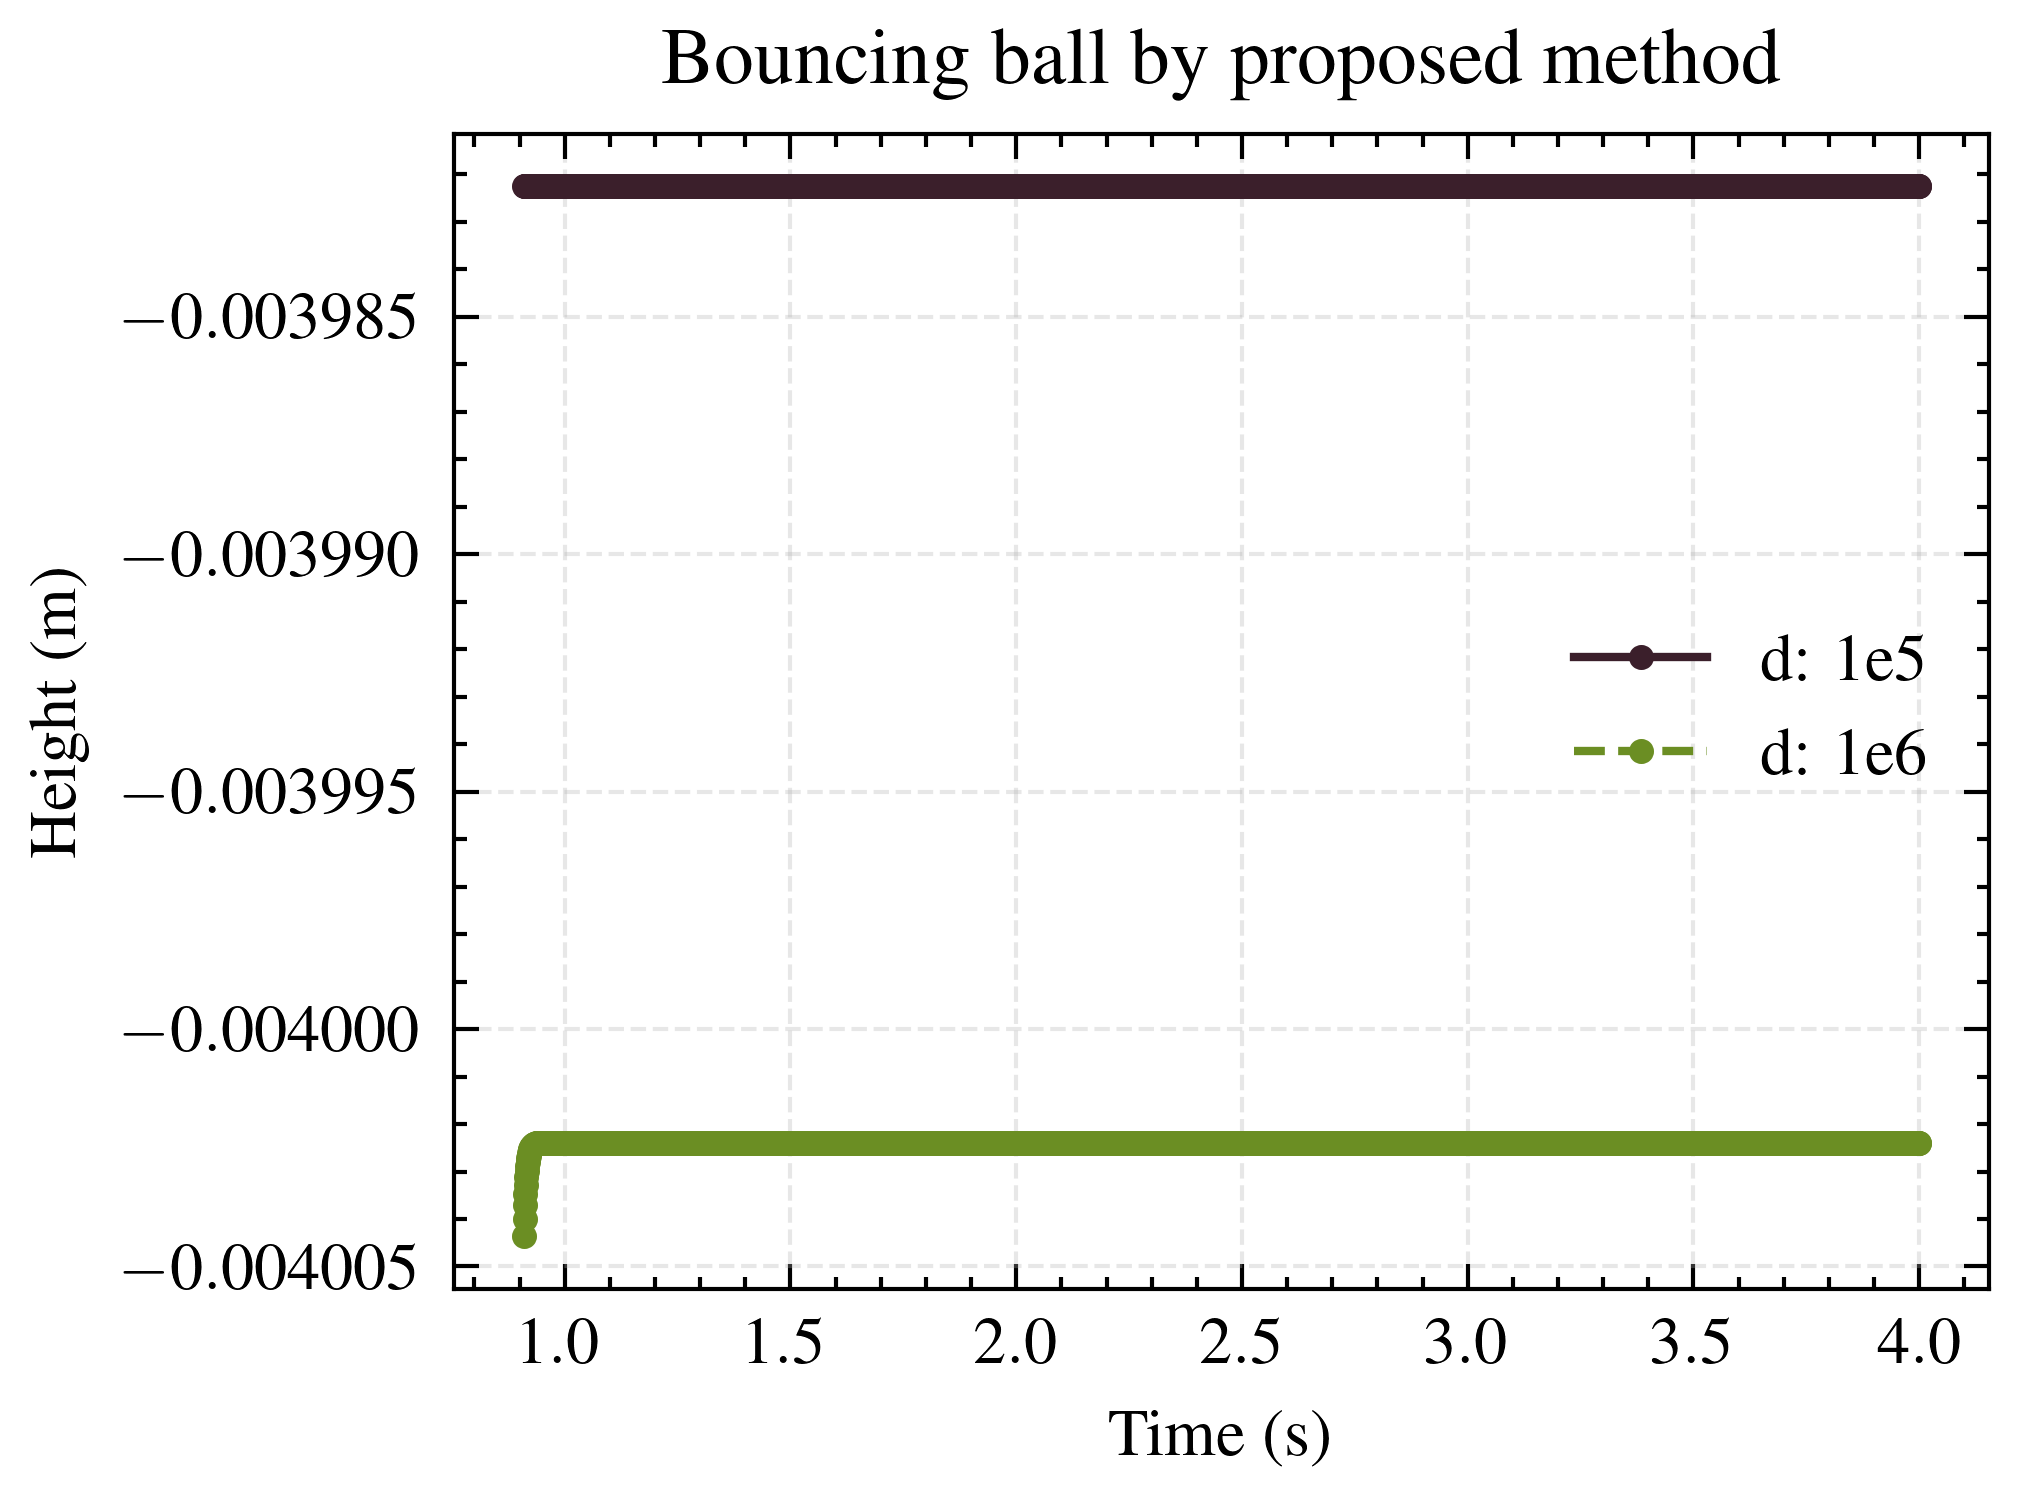

In [19]:
with plt.style.context(['science','ieee']):
  legendStrs = []
  linestyles = ["-","--", "-.", ":"]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    if i < 4:
      continue
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    print(result[i][2])
    
    lowerBound = sire.binarySearch(timeIndices, 0.91)
    upperBound = sire.binarySearch(timeIndices, 4)
    print(lowerBound, upperBound + 1)
    
    for j in range(lowerBound, upperBound + 1):
      # print(j, timeIndices[j], dts[j], partpq[j][1], partvs[j][1], partas[j][1], contactInfo[j])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"d: {simple_sci_format(parameters[i][1])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)')
  plt.xlabel(r'Time (s)')
  plt.title('Bouncing ball by proposed method')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [14]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e4, 0], [2e5, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
  print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  contact_solver_result = simulator.recordsContactCptInfo()
  result.append([displayInitJson, sim_result, contact_solver_result])


{k:20000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000.0,d:0,cof:0,threshold_velocity:1e-4}


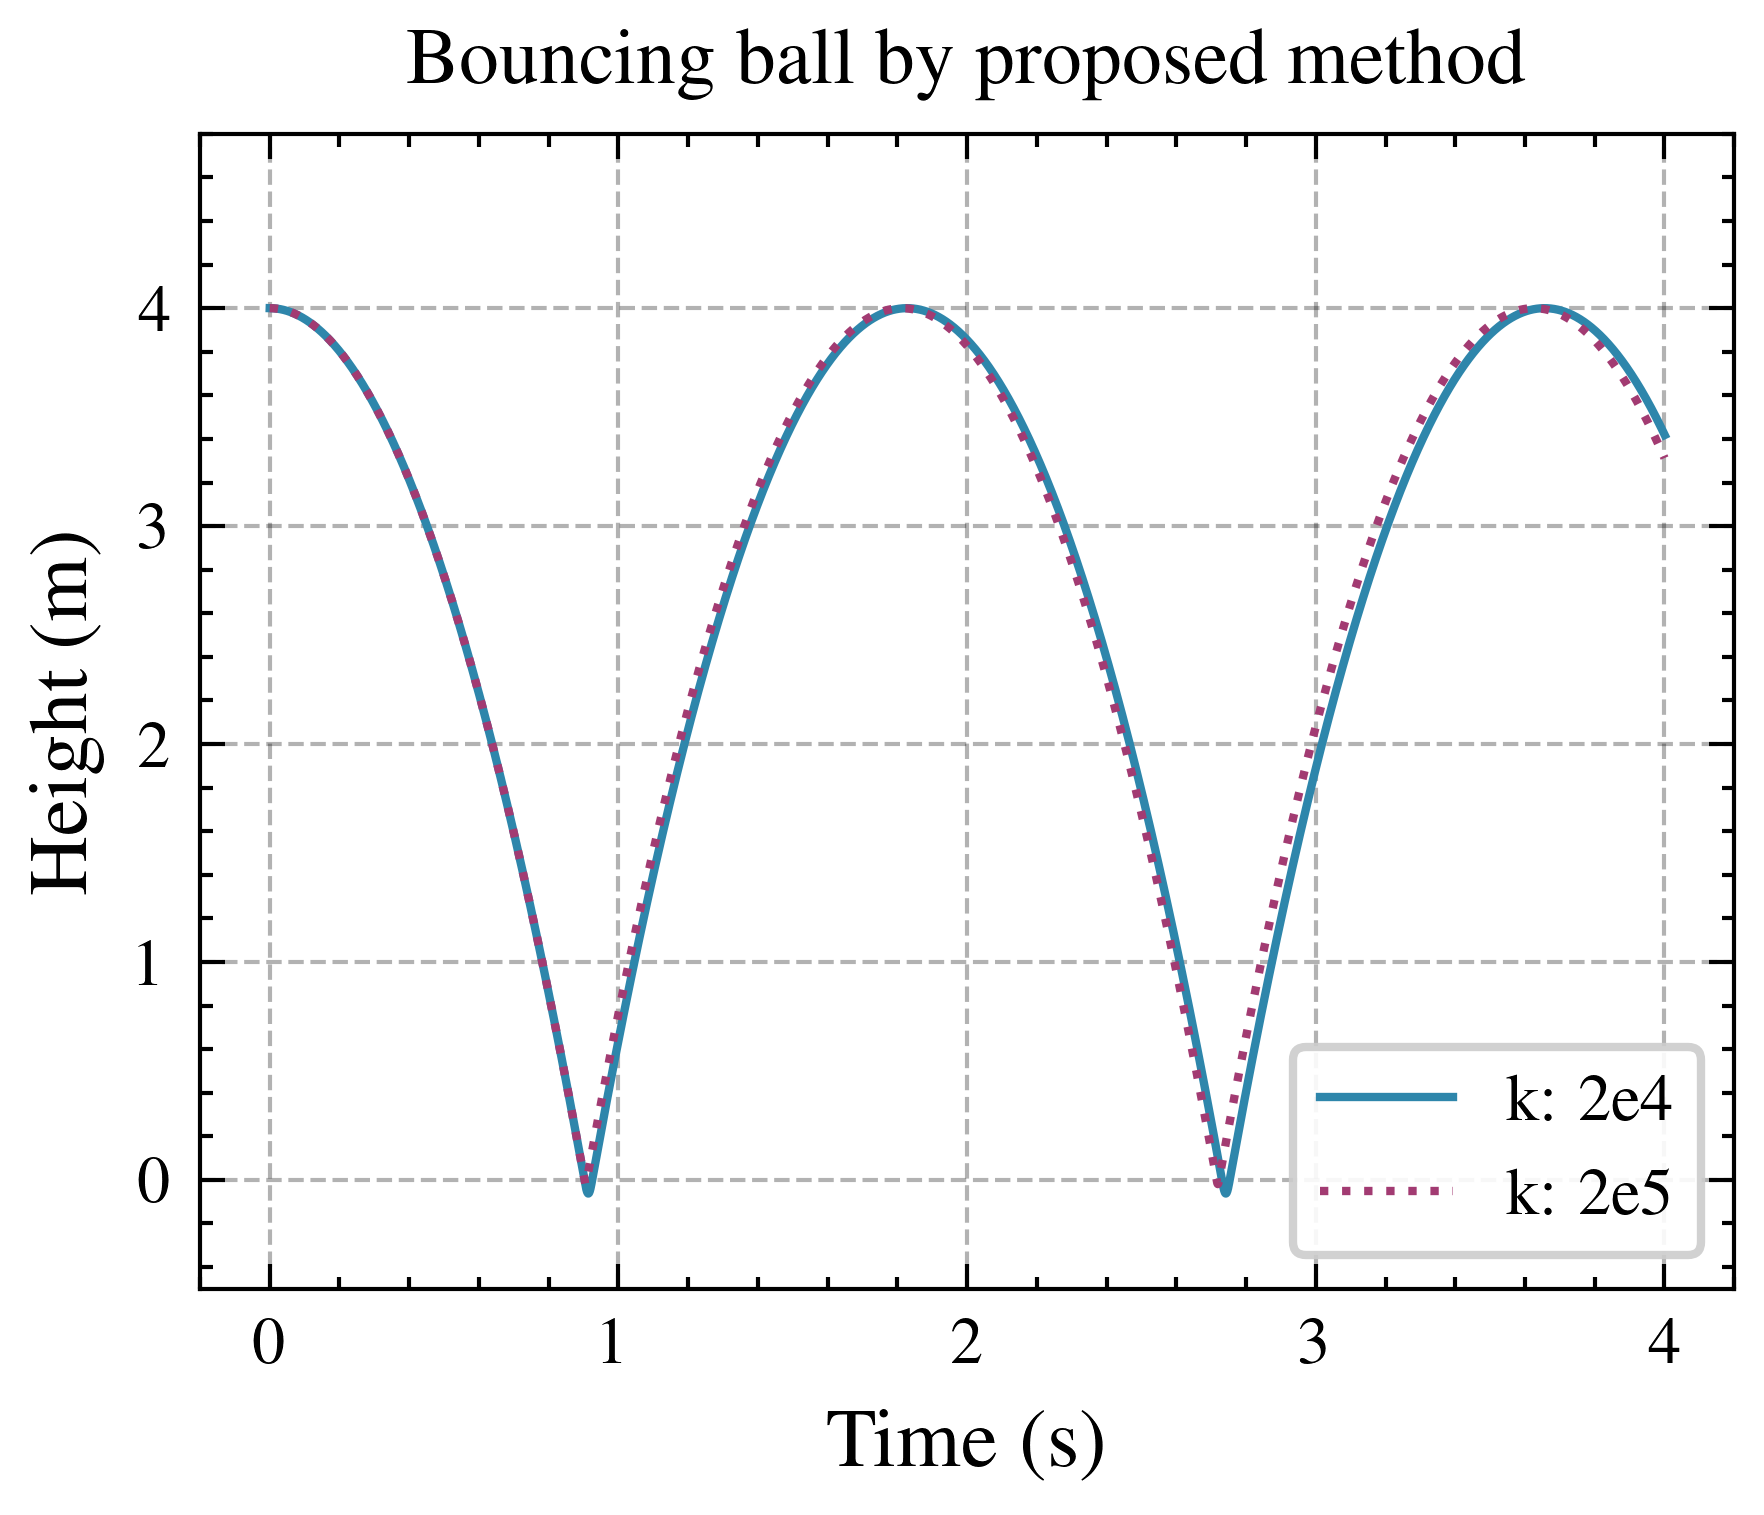

In [15]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0)
    upperBound = sire.binarySearch(timeIndices, 10)
    
    for j in range(lowerBound, upperBound + 1):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i % 4])
  
  # plt.legend(loc="best", fontsize=8)
  plt.legend(framealpha=0.9, loc="best")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  plt.ylim(top=4.8, bottom=-0.5)
  plt.title('Bouncing ball by proposed method')
  plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()
  plt.close()
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0)
    upperBound = sire.binarySearch(timeIndices, 10)
    
    for j in range(lowerBound, upperBound + 1):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i % 4])
  
  # plt.legend(loc="best", fontsize=8)
  plt.legend(framealpha=0.9, loc="best")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  plt.ylim(top=4.8, bottom=-0.5)
  # plt.title('Bouncing ball by proposed method')
  plt.grid(True, alpha=0.3)
  plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire_soft.pdf", format="pdf")
  # plt.show()
  plt.close()

{'currentTime': [0.9030000000000007, 0.9040000000000007, 0.9050000000000007, 0.9060000000000007, 0.9070000000000007, 0.9080000000000007, 0.9090000000000007, 0.9100000000000007, 0.9110000000000007, 0.9120000000000007, 0.9130000000000007, 0.9140000000000007, 0.9150000000000007, 0.9160000000000007, 0.9170000000000007, 0.9180000000000007, 0.9190000000000007, 0.9200000000000007, 0.9210000000000007, 0.9220000000000007, 0.9230000000000007, 0.9240000000000007, 0.9250000000000007, 2.7313251543983355, 2.7323251543983353, 2.7333251543983352, 2.734325154398335, 2.735325154398335, 2.736325154398335, 2.737325154398335, 2.7383251543983347, 2.7393251543983346, 2.7403251543983345, 2.7413251543983344, 2.7423251543983342, 2.743325154398334, 2.744325154398334, 2.745325154398334, 2.746325154398334, 2.7473251543983337, 2.7483251543983336, 2.7493251543983335, 2.7503251543983334, 2.7513251543983333, 2.752325154398333, 2.753325154398333], 'minTime': [0.022325154398519124, 0.02132515439857083, 0.020325154398460

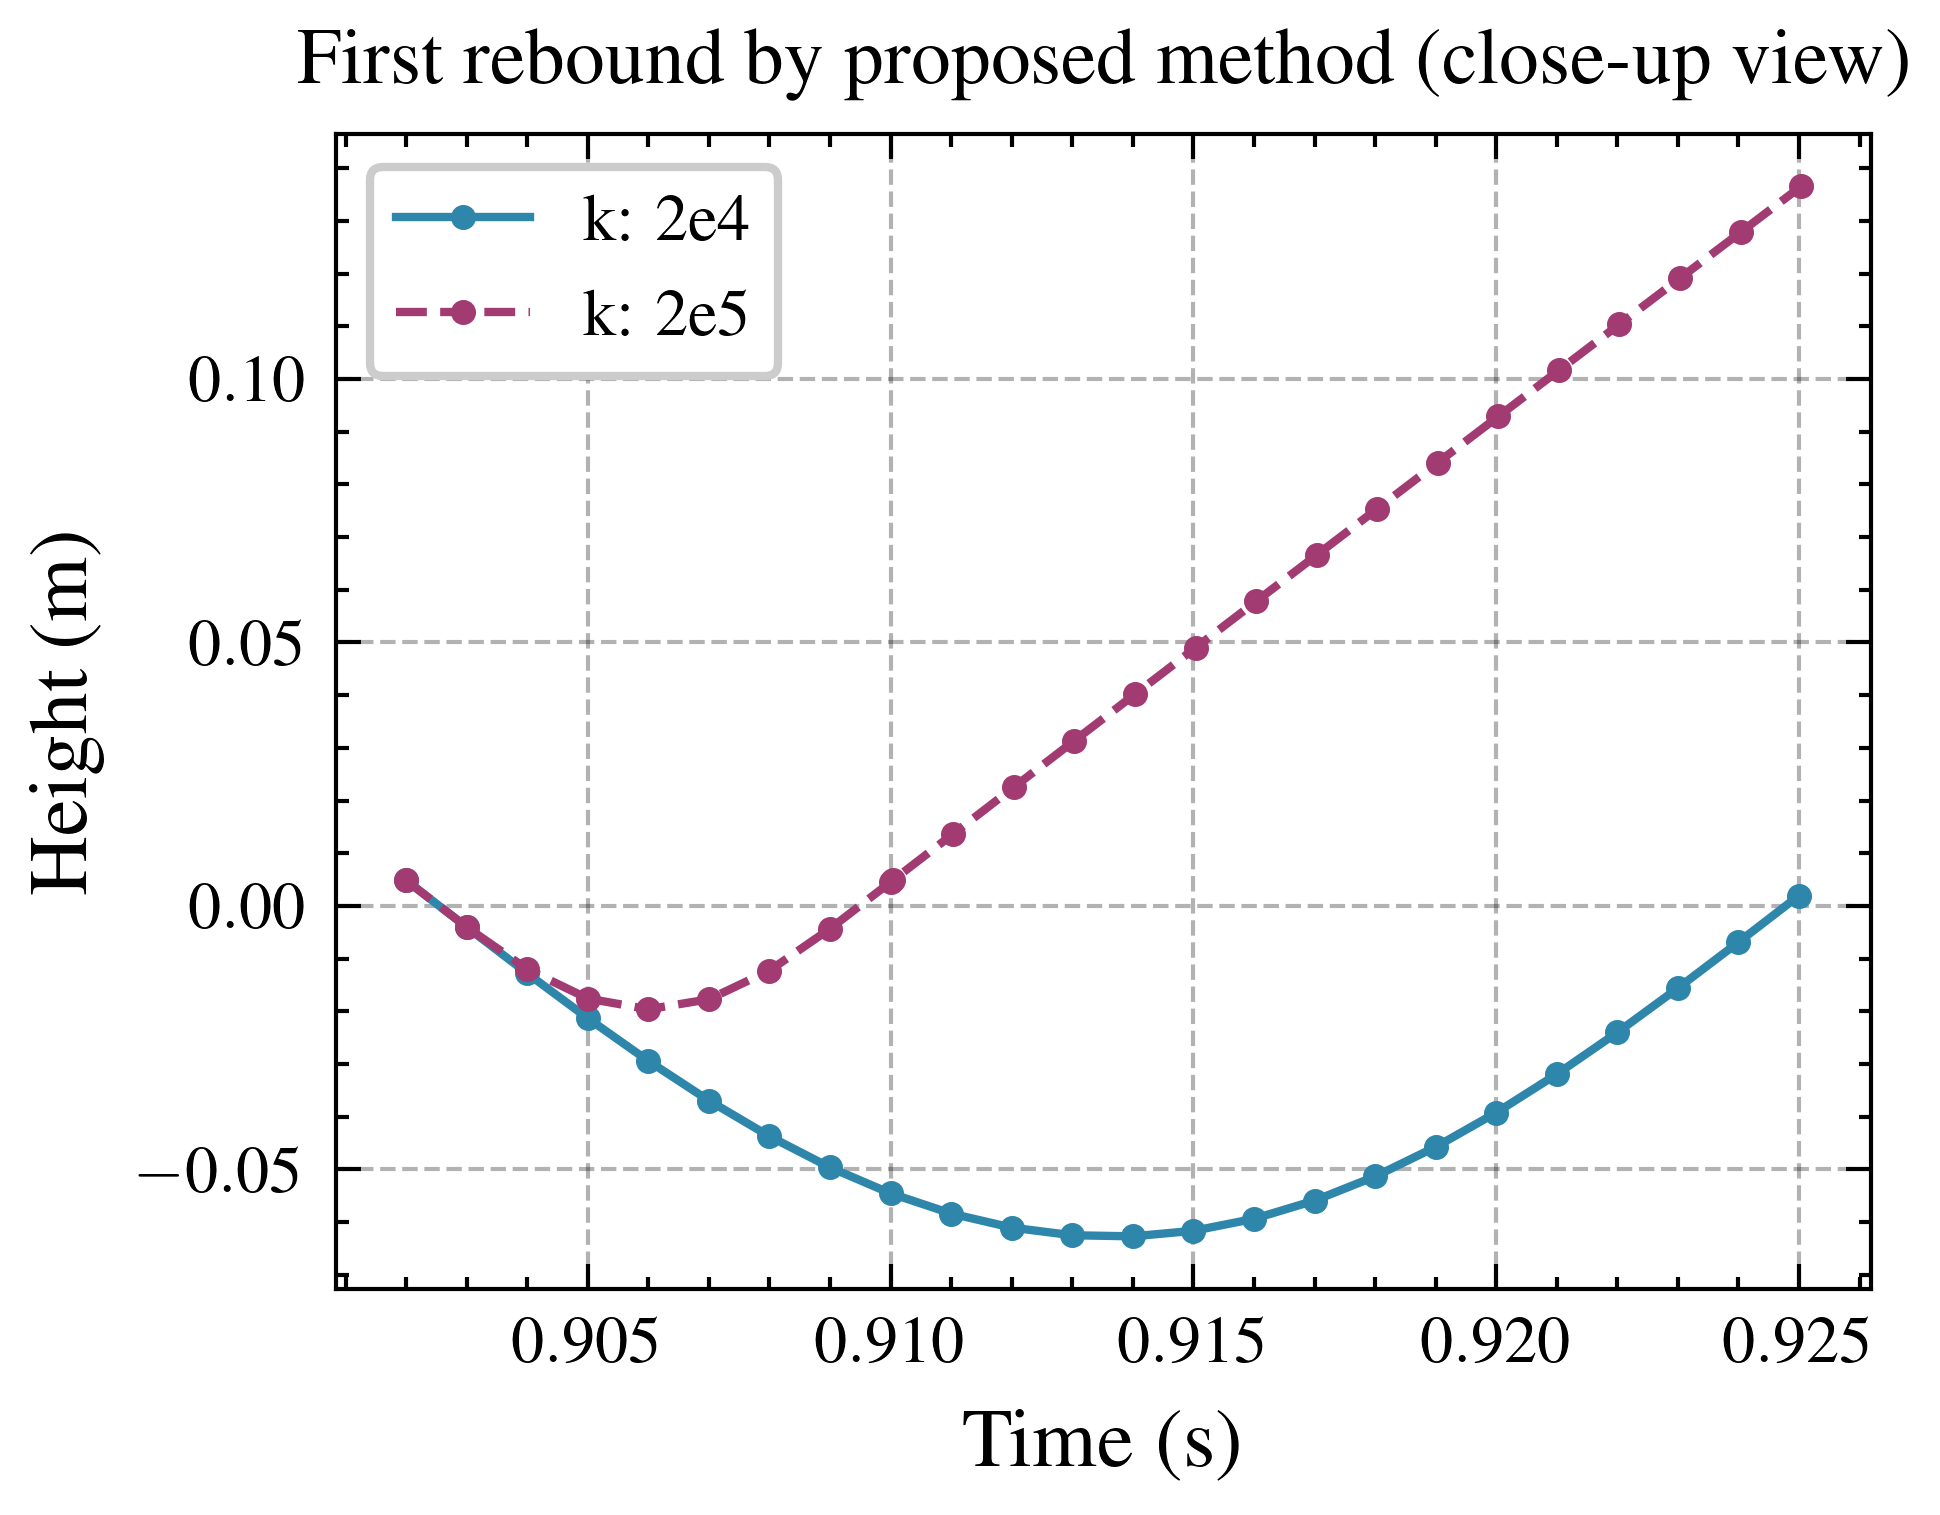

{'currentTime': [0.9030000000000007, 0.9040000000000007, 0.9050000000000007, 0.9060000000000007, 0.9070000000000007, 0.9080000000000007, 0.9090000000000007, 0.9100000000000007, 0.9110000000000007, 0.9120000000000007, 0.9130000000000007, 0.9140000000000007, 0.9150000000000007, 0.9160000000000007, 0.9170000000000007, 0.9180000000000007, 0.9190000000000007, 0.9200000000000007, 0.9210000000000007, 0.9220000000000007, 0.9230000000000007, 0.9240000000000007, 0.9250000000000007, 2.7313251543983355, 2.7323251543983353, 2.7333251543983352, 2.734325154398335, 2.735325154398335, 2.736325154398335, 2.737325154398335, 2.7383251543983347, 2.7393251543983346, 2.7403251543983345, 2.7413251543983344, 2.7423251543983342, 2.743325154398334, 2.744325154398334, 2.745325154398334, 2.746325154398334, 2.7473251543983337, 2.7483251543983336, 2.7493251543983335, 2.7503251543983334, 2.7513251543983333, 2.752325154398333, 2.753325154398333], 'minTime': [0.022325154398519124, 0.02132515439857083, 0.020325154398460

In [16]:
with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-","--", "-.", ":"]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    print(result[i][2])
    
    lowerBound = sire.binarySearch(timeIndices, 0.902)
    upperBound = sire.binarySearch(timeIndices, 0.925)
    print(lowerBound, upperBound + 1)
    
    for j in range(lowerBound, upperBound + 1):
      print(j, timeIndices[j], dts[j], partpq[j][1], partvs[j][1], partas[j][1], contactInfo[j])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  plt.title('First rebound by proposed method (close-up view)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()
  plt.close()
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    print(result[i][2])
    
    lowerBound = sire.binarySearch(timeIndices, 0.902)
    upperBound = sire.binarySearch(timeIndices, 0.925)
    print(lowerBound, upperBound + 1)
    
    for j in range(lowerBound, upperBound + 1):
      print(j, timeIndices[j], dts[j], partpq[j][1], partvs[j][1], partas[j][1], contactInfo[j])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  # plt.title('First rebound by proposed method (close-up view)')
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire_soft_zoomed.pdf", format="pdf")
  # plt.show()
  plt.close()

In [8]:
print(contact_solver_result)

{'currentTime': [0.9030000000000007, 0.9040000000000007], 'minTime': [0.0018145376439472343, 0.0008145376439388135], 'modifiedContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.858429999999922}], [{'depth': 0.005051860818282451, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': -1.4166885304332149}]], 'realContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.858429999999922}], [{'depth': 1e-07, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': -1.4166885304332144}]]}


## Performance Tests

### Duration 10s simulation profile without dissipation.

In [15]:
# test simulation time
import sire
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 10
dt = 0.001
ctrlt = 100
n = 40
timeCostResult = np.zeros([len(parameters), n])

for i in range(len(parameters)):
  # timeCost = 0
  for j in range(n):
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
    cs.init()
    simulator = sire.simulationLoop(cs)
    pe = cs.physicsEngine()
    simulator.simDuration = sim_duration
    simulator.deltaT = dt
    simulator.ctrlT = ctrlt
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    # print(contactPropStr)
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    start = time.perf_counter()
    while(not simulator.isTimeout()):
      simulator.step(1, False)
    end = time.perf_counter()
    elapsed = end - start
    timeCostResult[i][j] = elapsed
    # timeCost += elapsed
  # timeCostResult.append(timeCost)

# Save time cost data csv
np.savetxt(
    'sire_perf_measure_10s_zero_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

In [17]:
data = np.genfromtxt('sire_perf_measure_10s_zero_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[0.10162964 0.05951976 0.05422211 0.05691037]


### Duration 10s simulation profile with high dissipation.

In [ ]:
# test simulation time
import sire
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
parameters = [[2e3, ], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 100
n = 40
timeCostResult = np.zeros([len(parameters), n])

for i in range(len(parameters)):
  # timeCost = 0
  for j in range(n):
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
    cs.init()
    simulator = sire.simulationLoop(cs)
    pe = cs.physicsEngine()
    simulator.simDuration = sim_duration
    simulator.deltaT = dt
    simulator.ctrlT = ctrlt
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    # print(contactPropStr)
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    start = time.perf_counter()
    while(not simulator.isTimeout()):
      simulator.step(1, False)
    end = time.perf_counter()
    elapsed = end - start
    timeCostResult[i][j] = elapsed
    # timeCost += elapsed
  # timeCostResult.append(timeCost)

# Save time cost data csv
np.savetxt(
    'sire_perf_measure_10s_zero_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

In [ ]:
data = np.genfromtxt('sire_perf_measure_10s_zero_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[0.10162964 0.05951976 0.05422211 0.05691037]


### Contact profile

In [ ]:
# test simulation time
import sire
import numpy as np
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 10
dt = 0.001
ctrlt = 100
n = 1000
timeCostResult = np.zeros([len(parameters), n])

for i in range(len(parameters)):
  # timeCost = 0
  for j in range(n):
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/profile_contact.xml")
    cs.init()
    simulator = sire.simulationLoop(cs)
    pe = cs.physicsEngine()
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    # print(contactPropStr)
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    isCtrl = simulator.integrate()
    start = time.perf_counter()
    simulator.handleContact()
    end = time.perf_counter()
    elapsed = end - start
    timeCostResult[i][j] = elapsed
    # timeCost += elapsed
  # timeCostResult.append(timeCost)

# Save time cost data csv
np.savetxt(
    'sire_perf_measure_contact.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

In [ ]:
data = np.genfromtxt('sire_perf_measure_contact.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[0.00016098 0.00017034 0.00017037 0.00018256]


## Parameter k Range Tests

In [153]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
start = 200
end = 2e45
num_points = 1000  # 你需要的点数

# 最简单的方法
parameters = np.geomspace(start, end, num_points)
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i]},d:0,cof:0,threshold_velocity:1e-4}}"
  # print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  # displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  # contact_solver_result = simulator.recordsContactCptInfo()
  result.append(sim_result)

heights = np.zeros(np.size(parameters))
for i in range(len(parameters)):
  pltResult = result[i]
  timeIndices = pltResult['timeIndex']
  partpq = pltResult["partPq"]
  
  lowerBound = 900
  upperBound = sire.binarySearch(timeIndices, 2.2)
  firstBounceHeight = 0
  for j in range(900, upperBound + 1):
    # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
    height = partpq[j][1][2]-0.5
    if height > firstBounceHeight:
       firstBounceHeight = height
  heights[i] = firstBounceHeight - 4

if len(heights) == len(parameters):
  # Save first bouncing height data csv
  np.savetxt(
      'first_bouncing_data.csv',          # Filename
      np.column_stack((parameters, heights)),  # Combine x and y into two columns
      delimiter=',',            # Use comma as delimiter
      header='stiffness,height',             # Column headers
      comments=''               # Remove '#' from header
  )

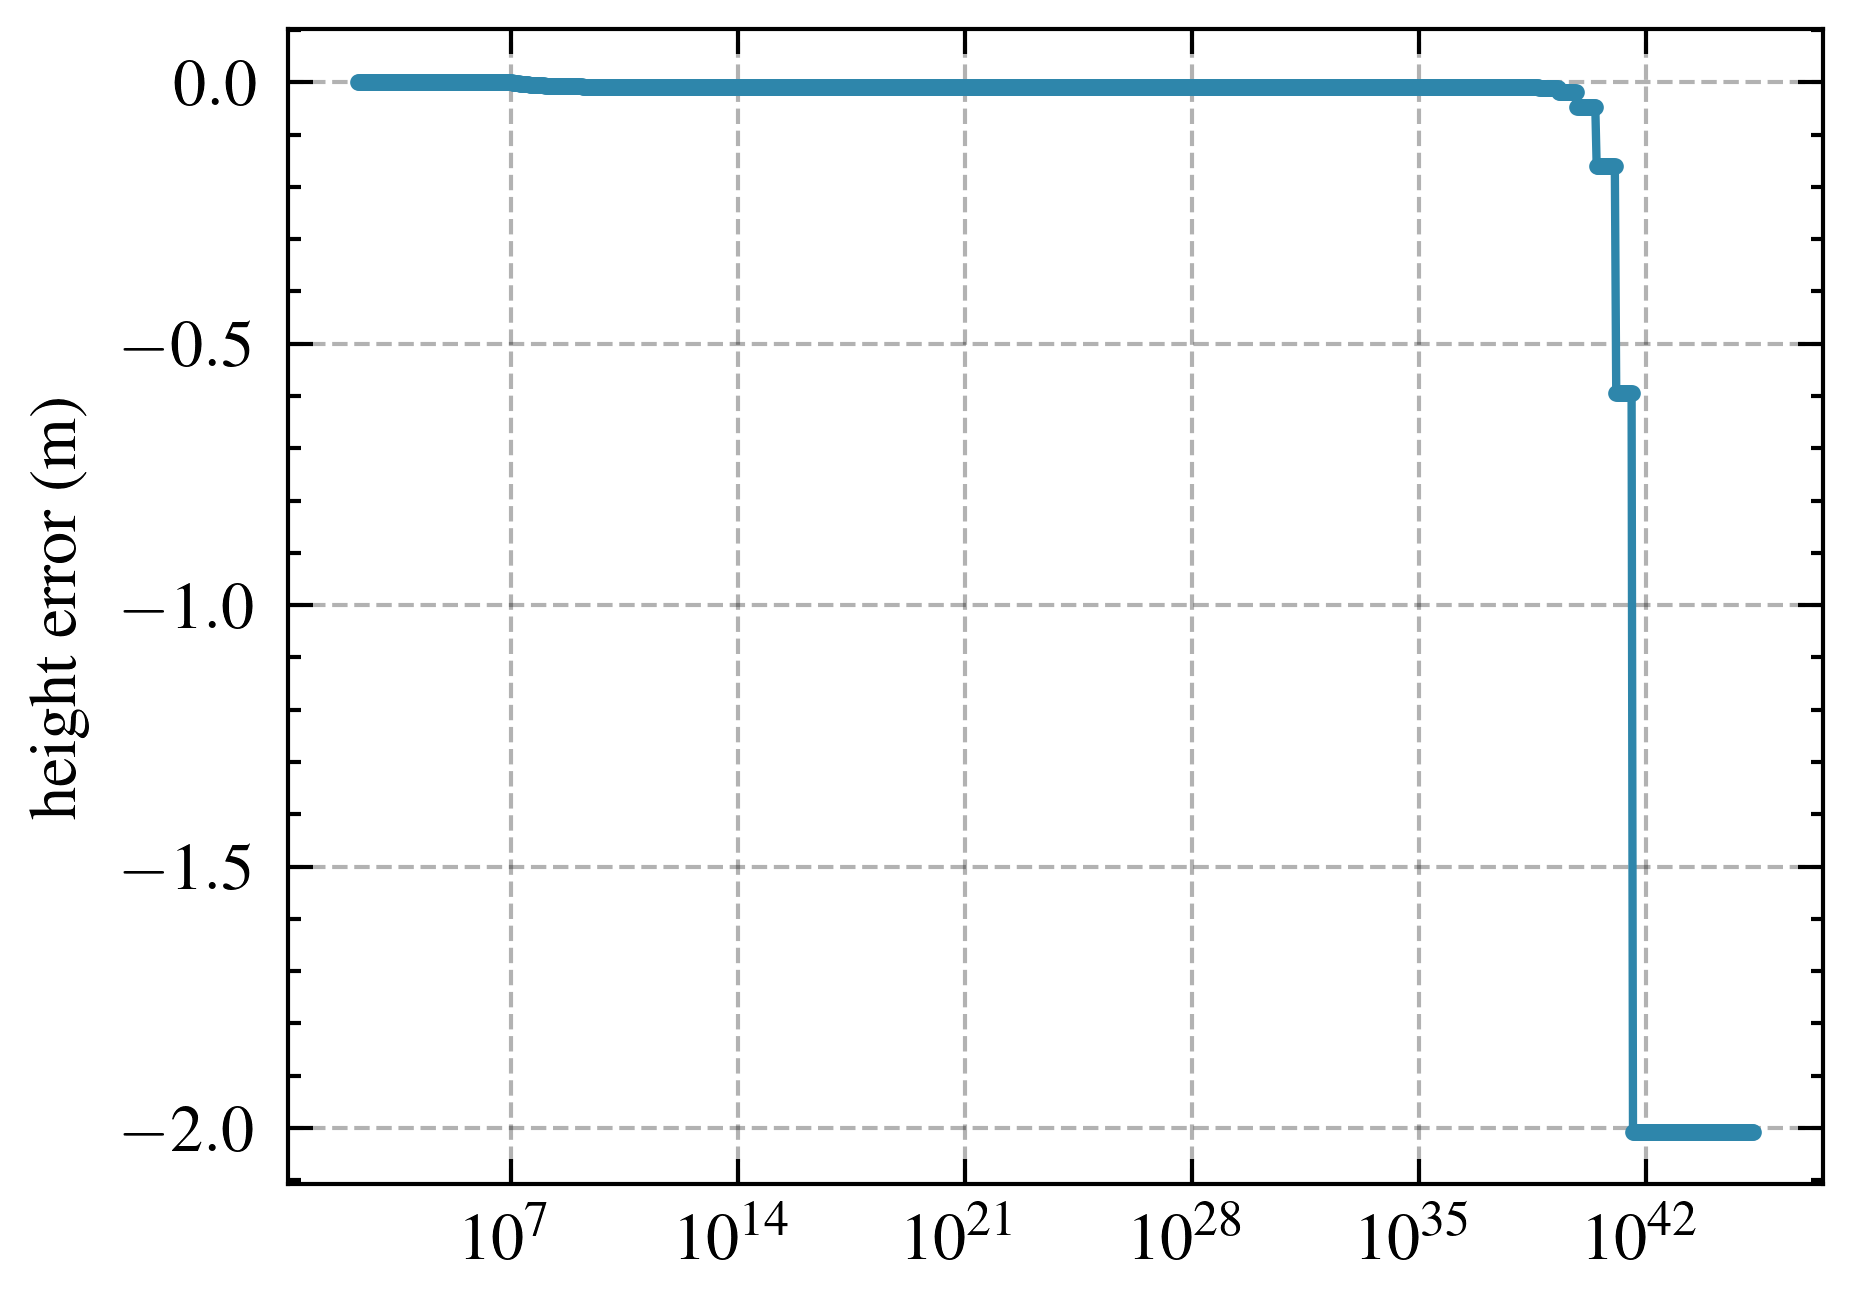

In [124]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  plt.semilogx(parameters, heights, marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

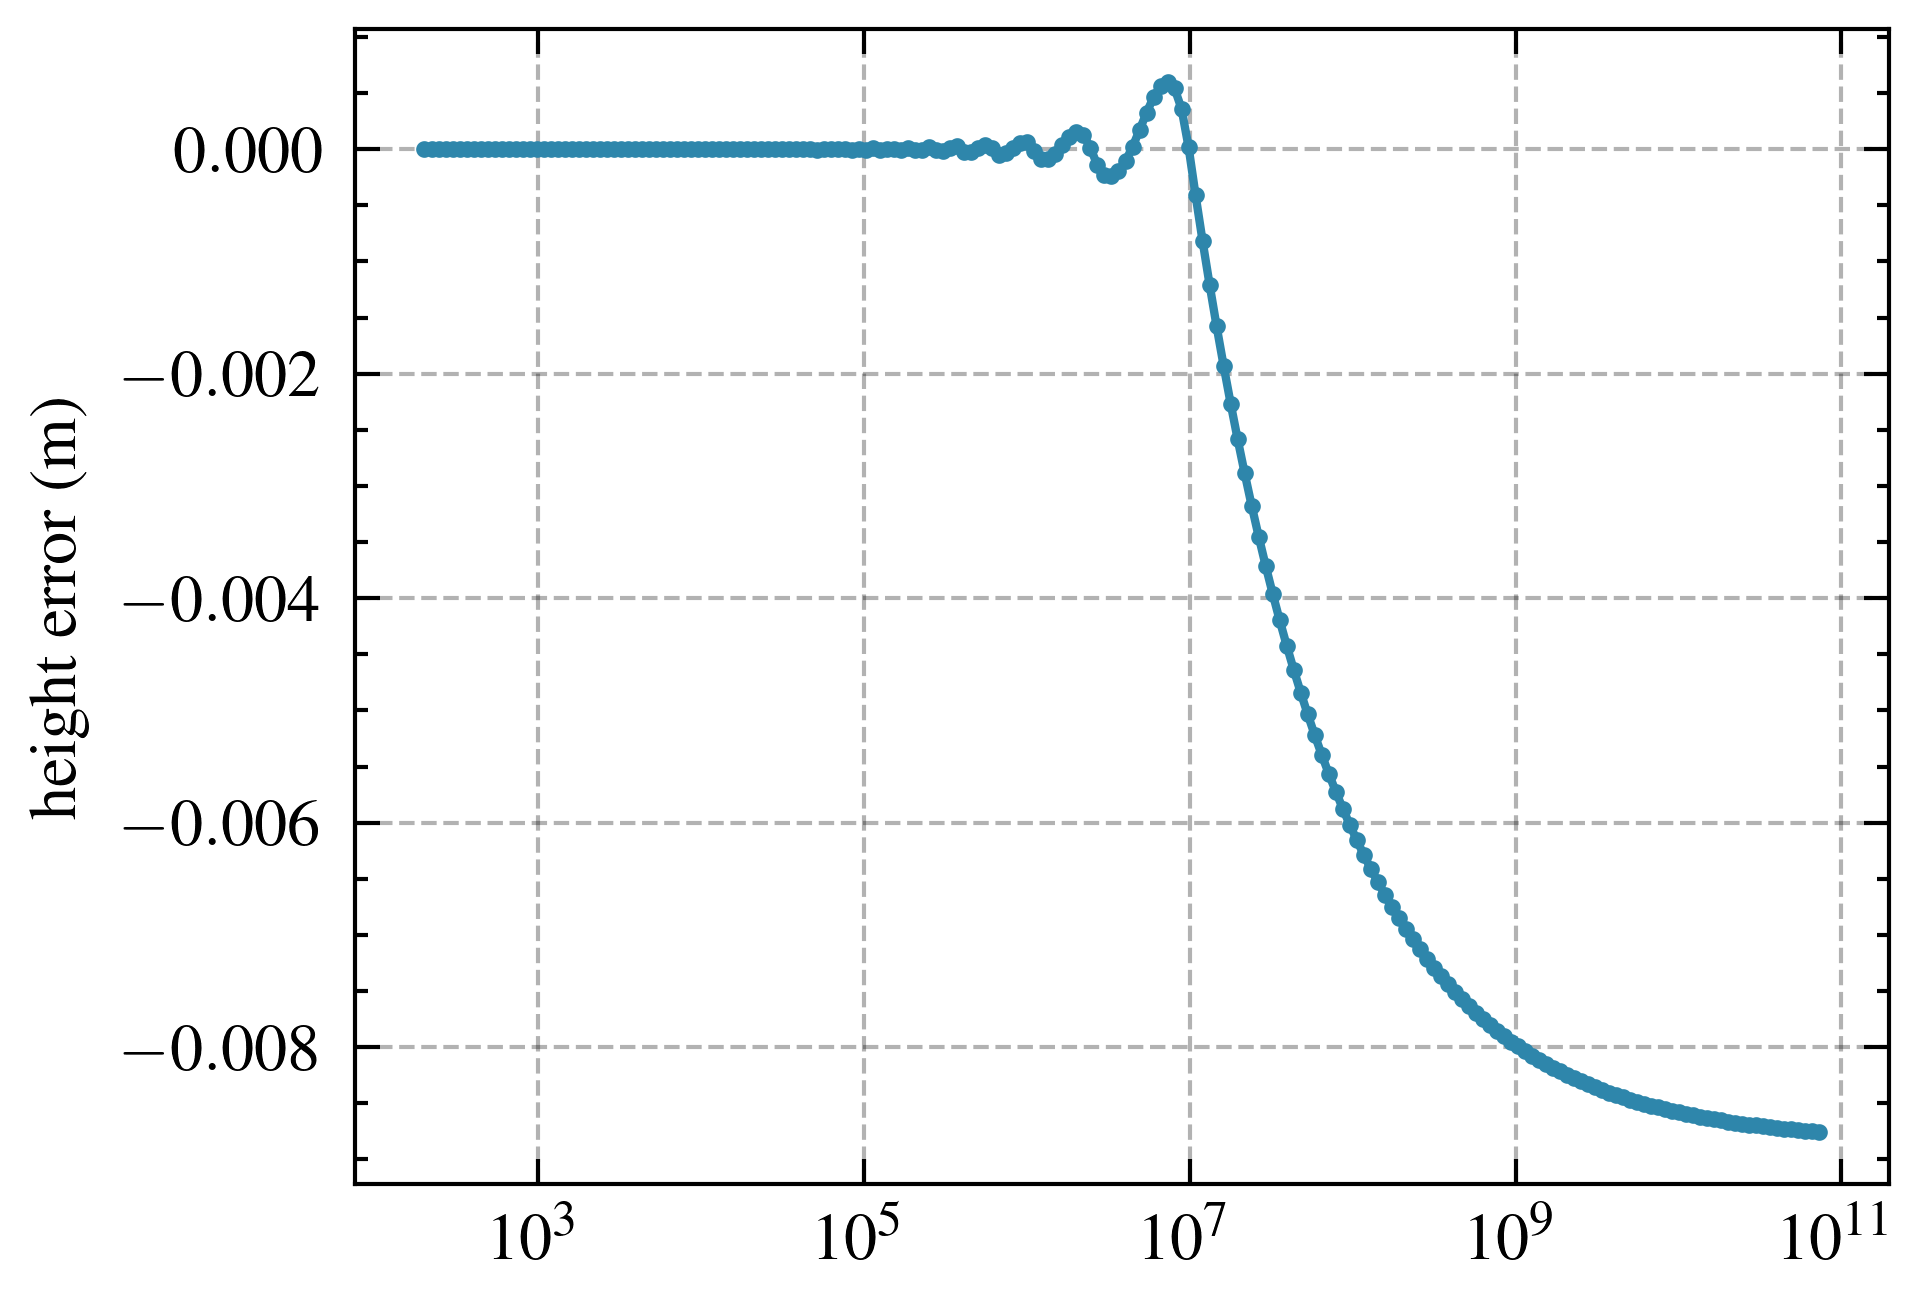

In [127]:
n = -800
with plt.style.context(['science','ieee', 'grid']):
  plt.semilogx(parameters[:n], heights[:n], marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # print(parameters[:n], heights[:n])
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

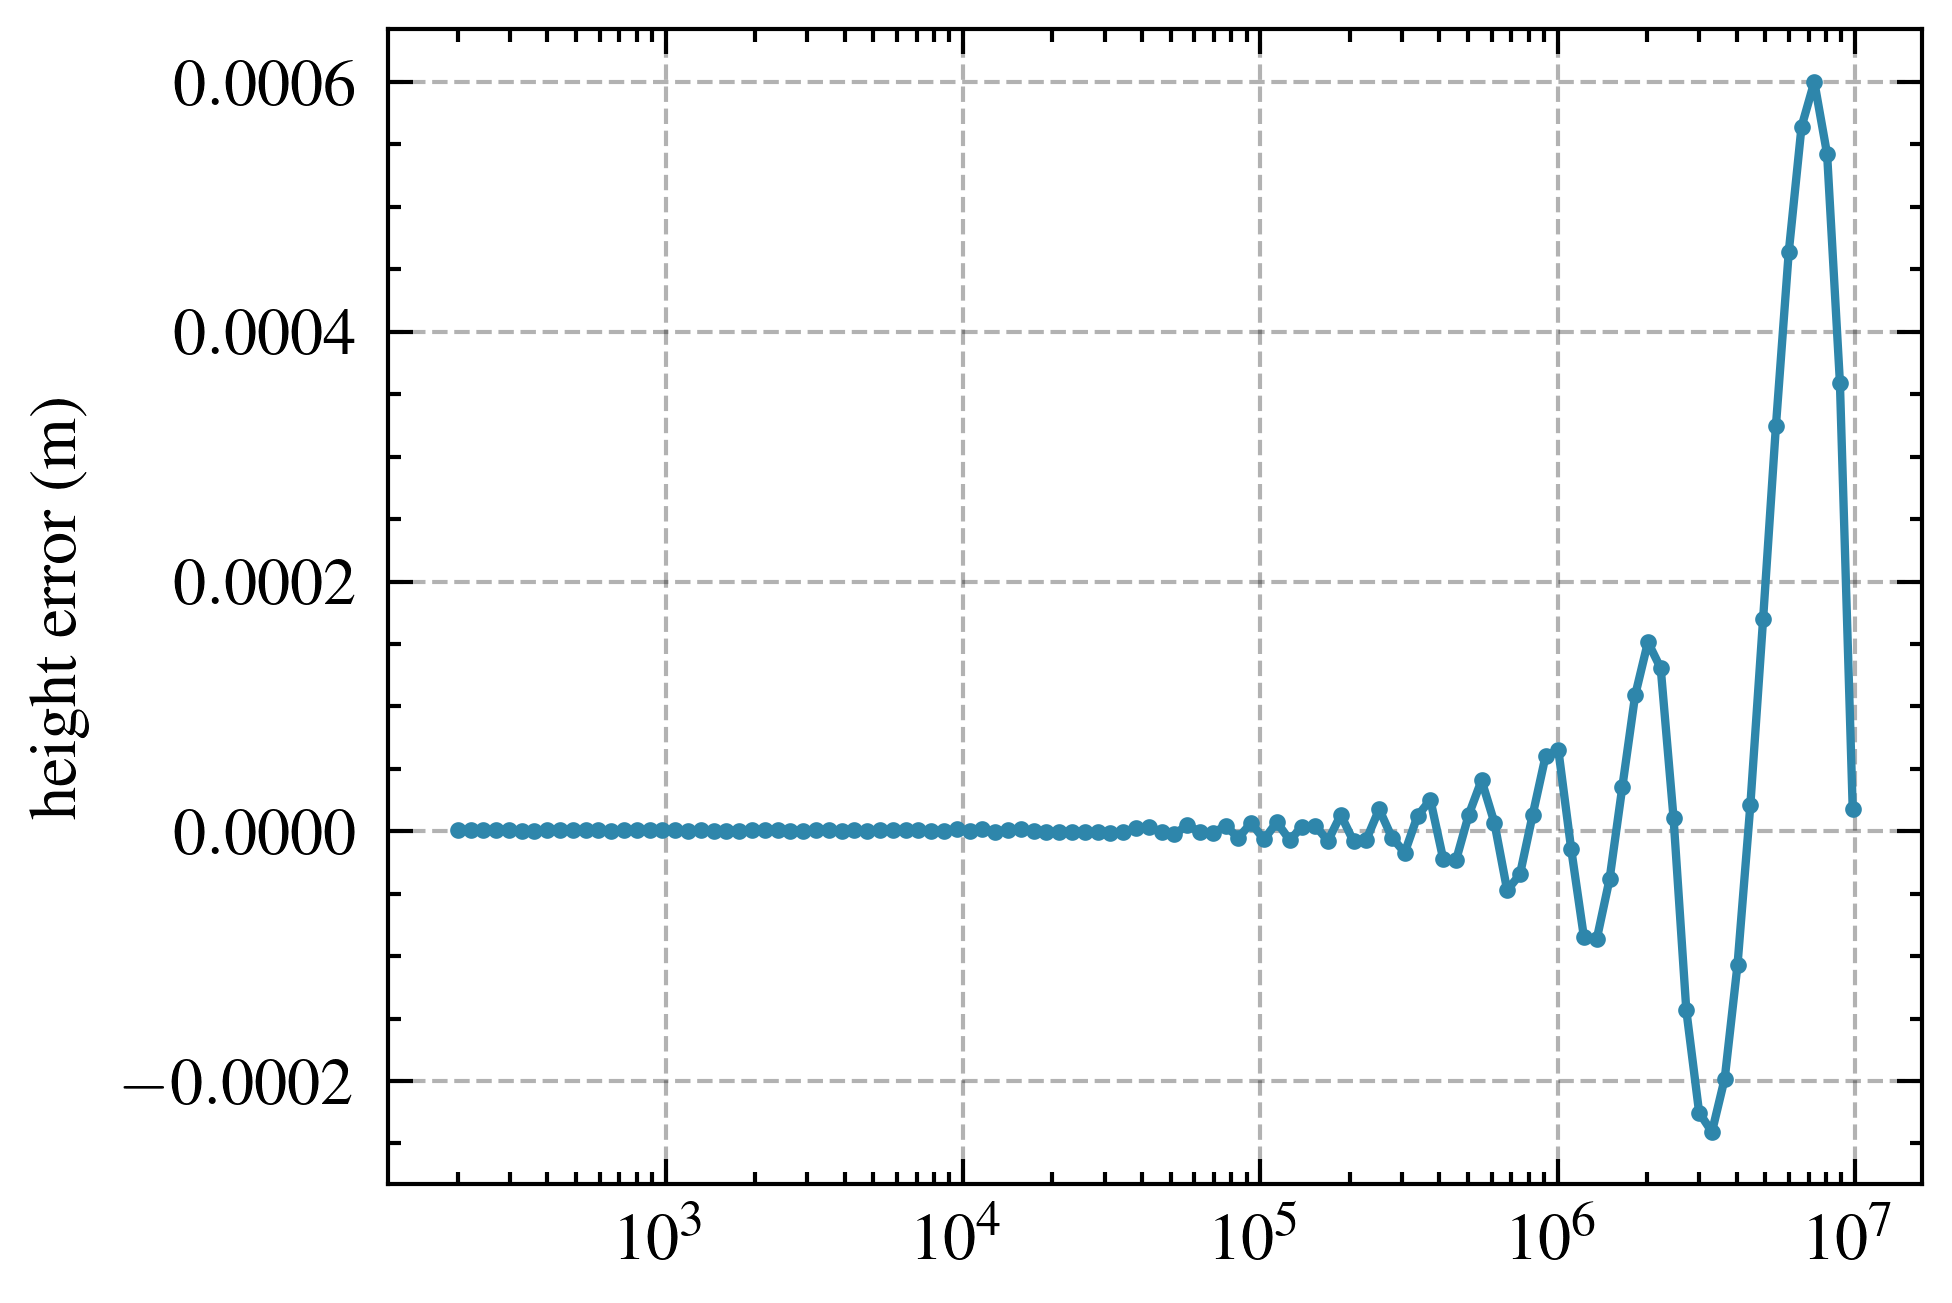

In [128]:
n = -890
with plt.style.context(['science','ieee', 'grid']):
  plt.semilogx(parameters[:n], heights[:n], marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [ ]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
start = 200
end = 2e8
num_points = 1000  # 你需要的点数

# 最简单的方法
parameters = np.geomspace(start, end, num_points)
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i]},d:0,cof:0,threshold_velocity:1e-4}}"
  # print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  # displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  # contact_solver_result = simulator.recordsContactCptInfo()
  result.append(sim_result)

heights = np.zeros(np.size(parameters))
for i in range(len(parameters)):
  pltResult = result[i]
  timeIndices = pltResult['timeIndex']
  partpq = pltResult["partPq"]
  
  lowerBound = 900
  upperBound = sire.binarySearch(timeIndices, 2.2)
  firstBounceHeight = 0
  for j in range(900, upperBound + 1):
    # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
    height = partpq[j][1][2]-0.5
    if height > firstBounceHeight:
       firstBounceHeight = height
  heights[i] = firstBounceHeight - 4

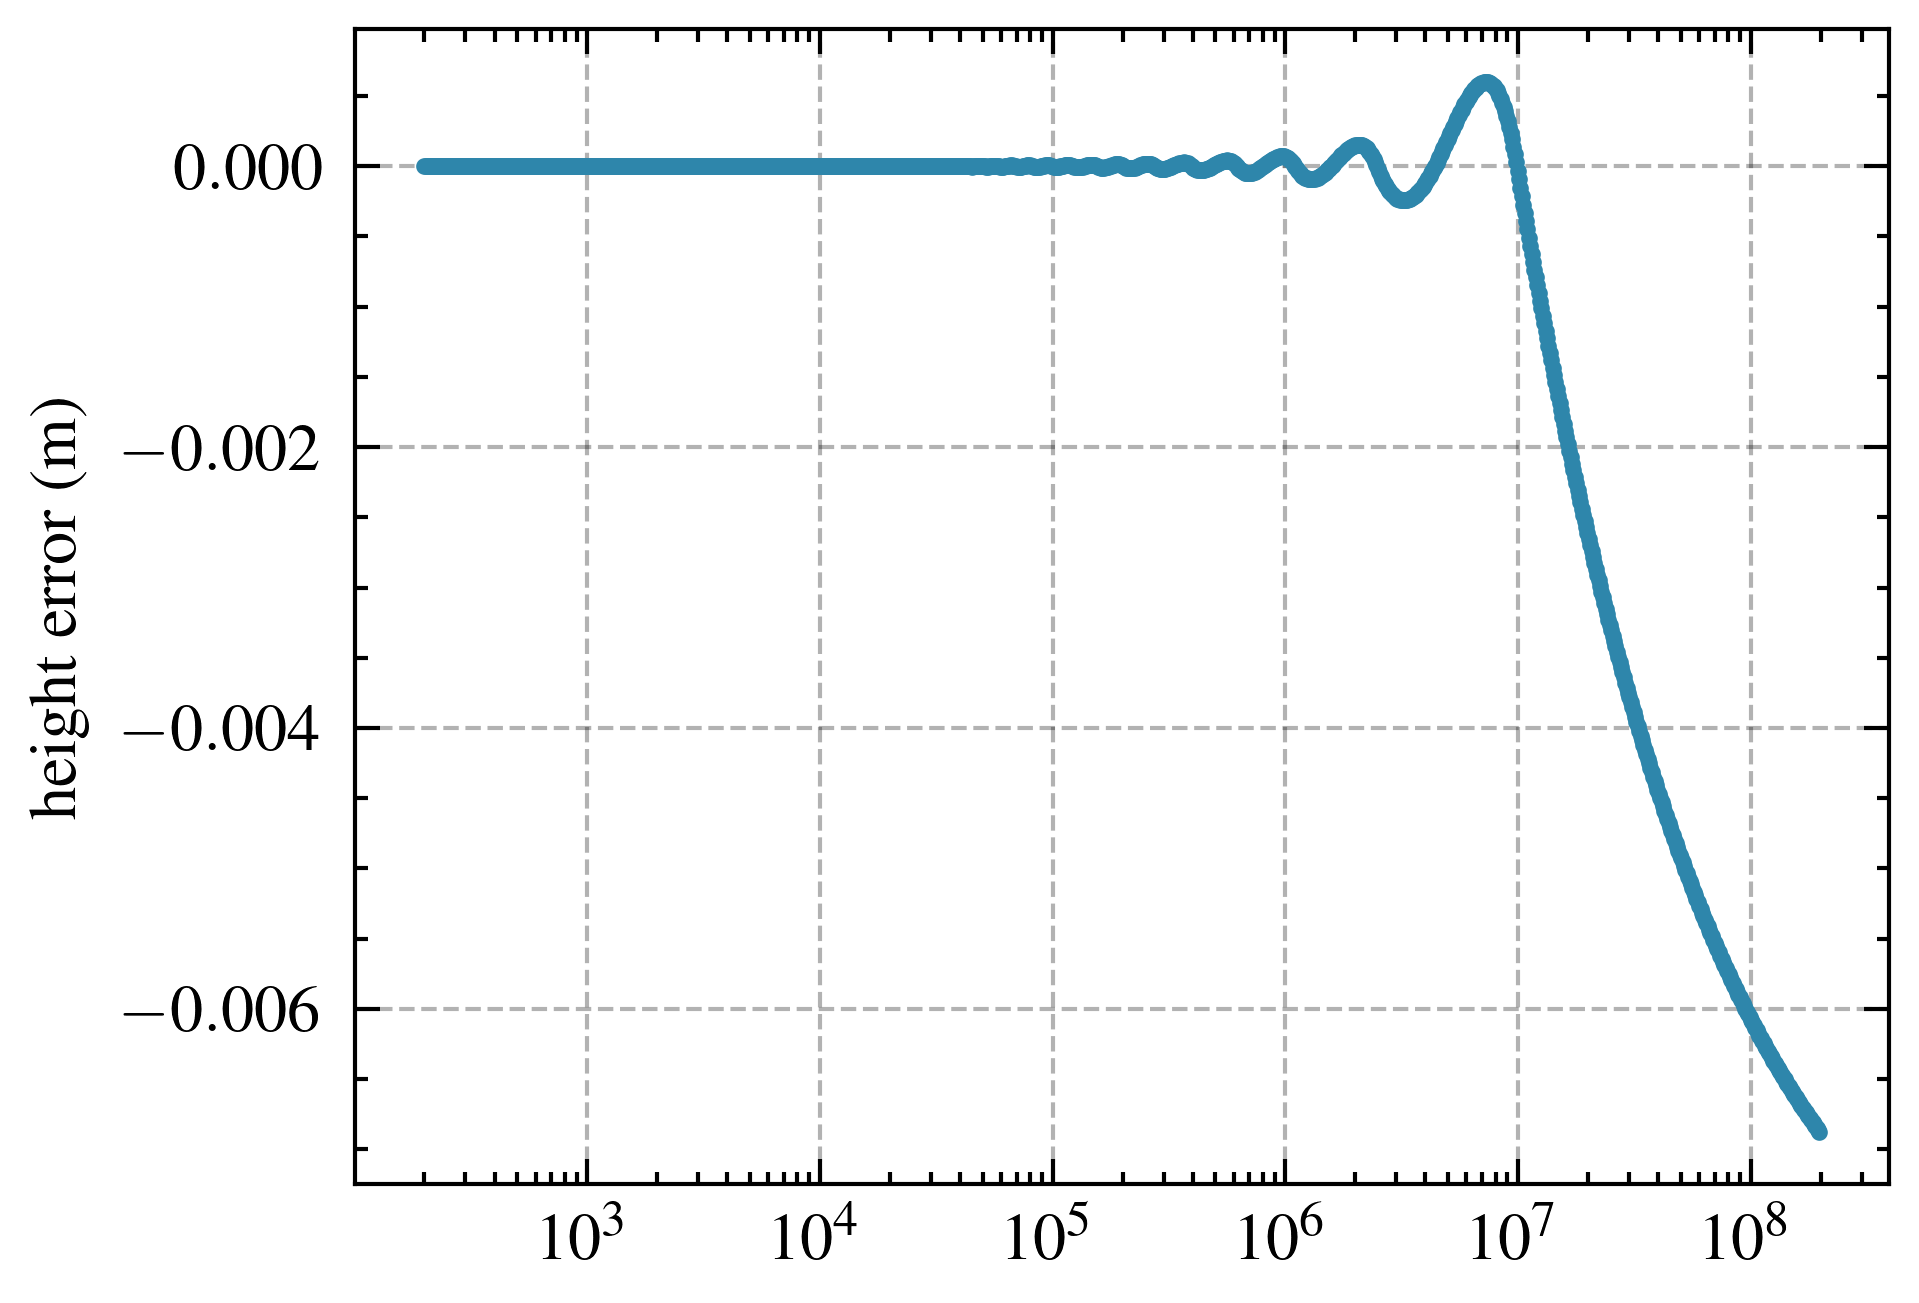

In [132]:
n = -1
with plt.style.context(['science','ieee', 'grid']):
  plt.semilogx(parameters[:n], heights[:n], marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # print(parameters[:n], heights[:n])
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

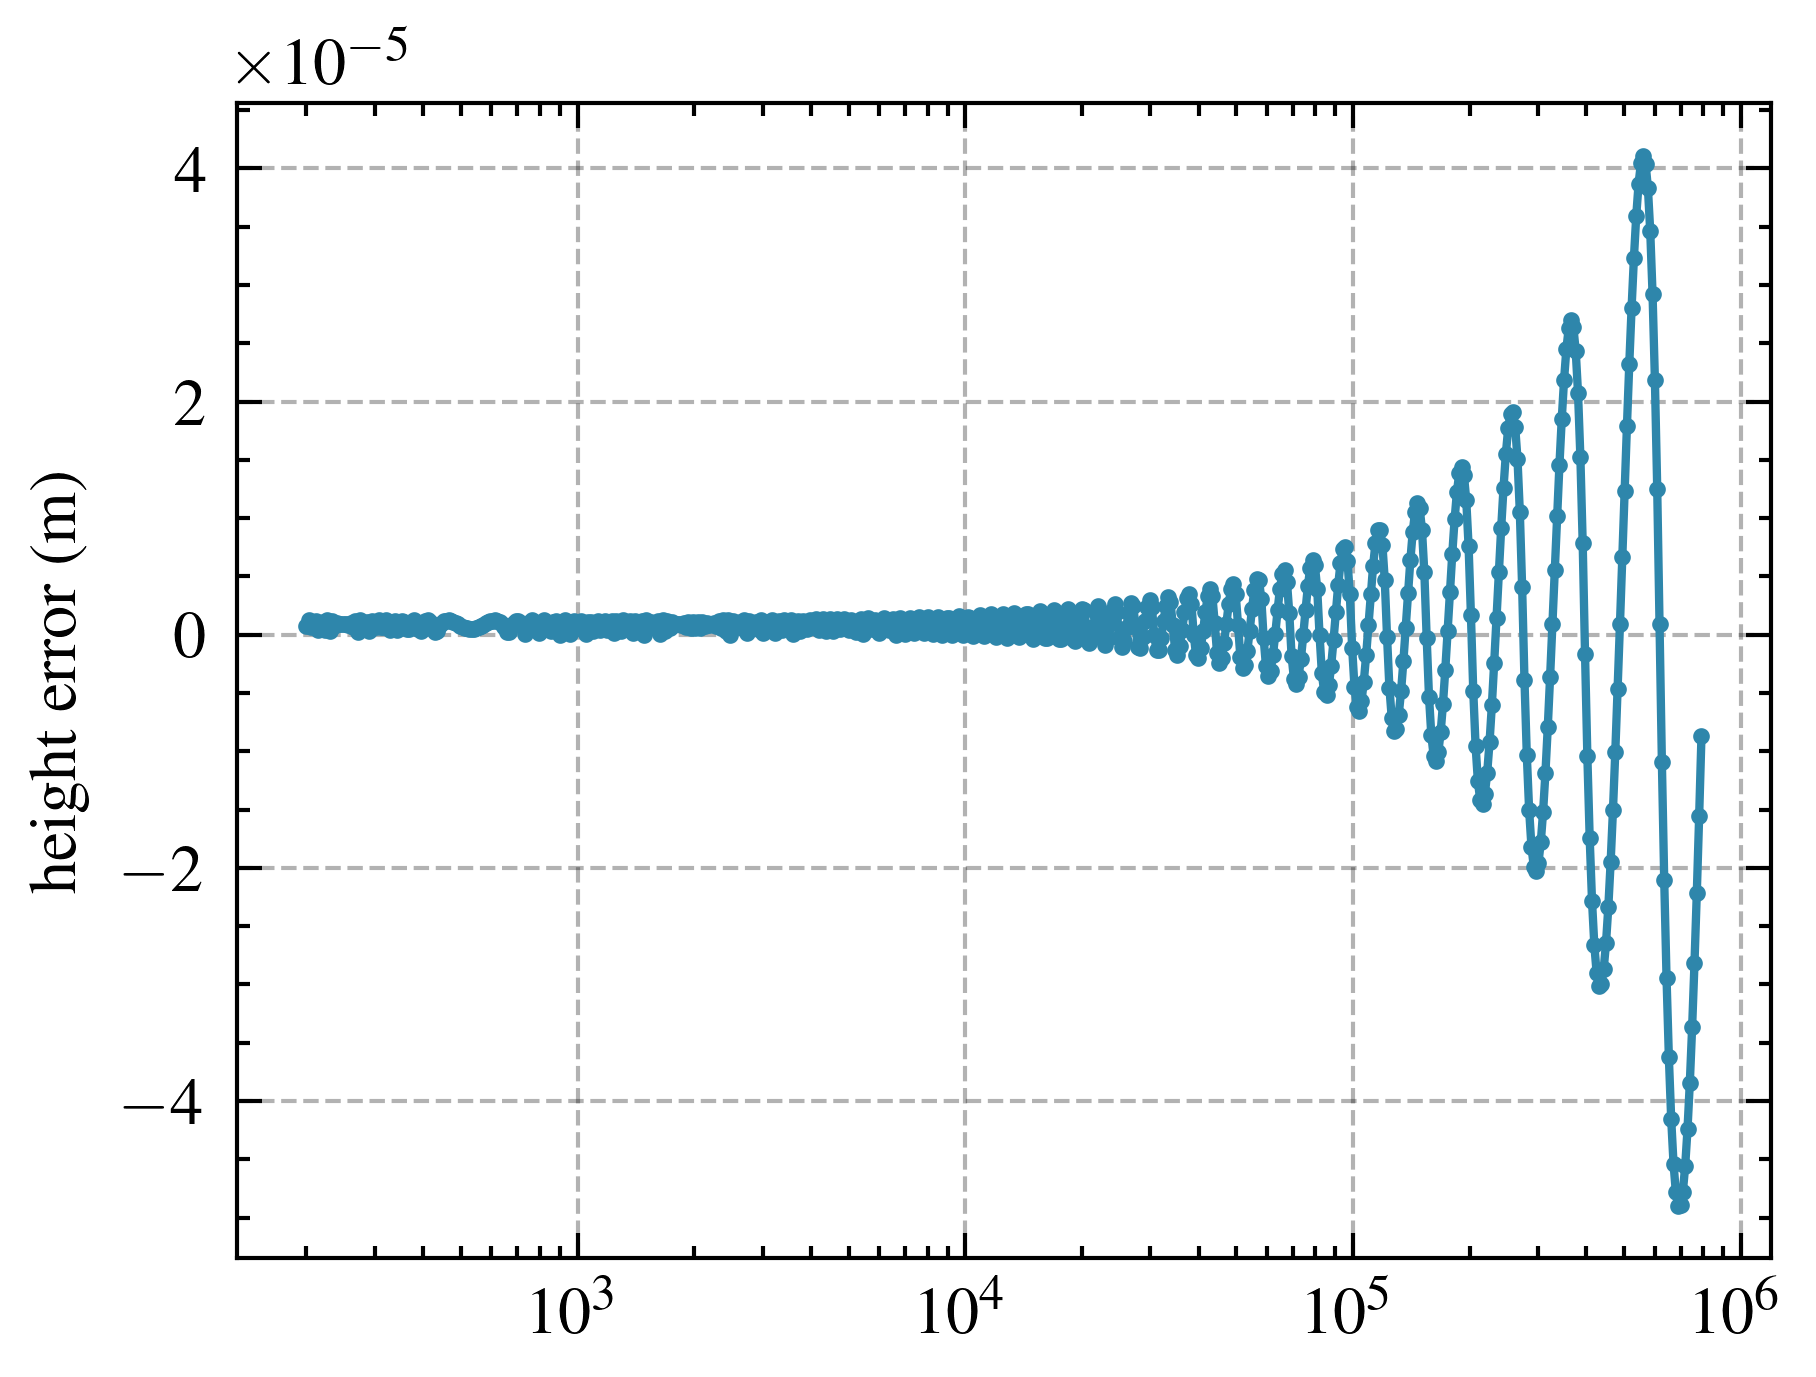

In [134]:
n = -400
with plt.style.context(['science','ieee', 'grid']):
  plt.semilogx(parameters[:n], heights[:n], marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [ ]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
start = 200
end = 1e4
num_points = 1000  # 你需要的点数

# 最简单的方法
parameters = np.geomspace(start, end, num_points)
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i]},d:0,cof:0,threshold_velocity:1e-4}}"
  # print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  # displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  # contact_solver_result = simulator.recordsContactCptInfo()
  result.append(sim_result)

heights = np.zeros(np.size(parameters))
for i in range(len(parameters)):
  pltResult = result[i]
  timeIndices = pltResult['timeIndex']
  partpq = pltResult["partPq"]
  
  lowerBound = 900
  upperBound = sire.binarySearch(timeIndices, 2.2)
  firstBounceHeight = 0
  for j in range(900, upperBound + 1):
    # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
    height = partpq[j][1][2]-0.5
    if height > firstBounceHeight:
       firstBounceHeight = height
  heights[i] = firstBounceHeight - 4

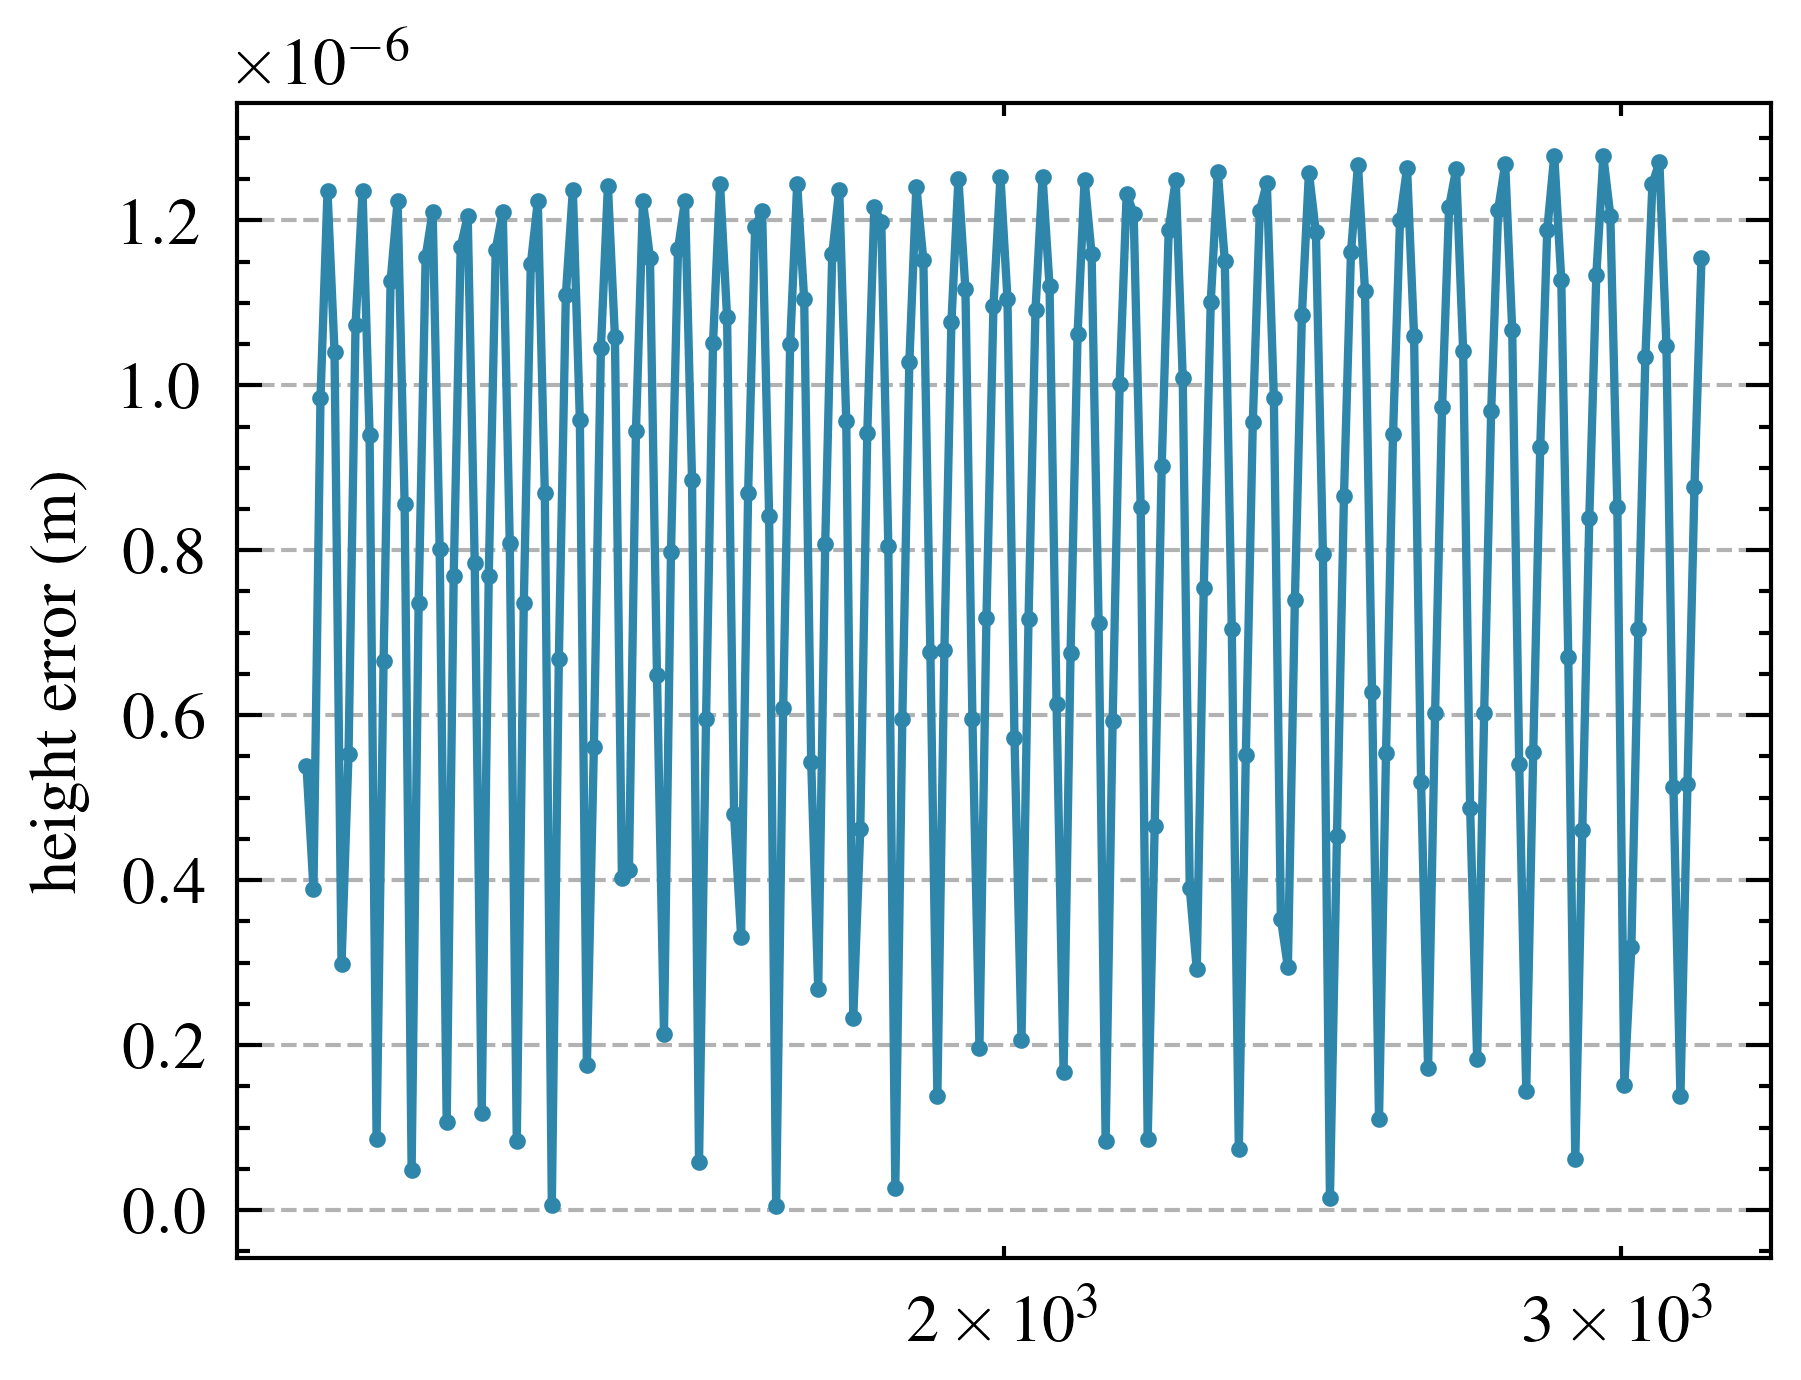

In [143]:
start = 400
n = -400
with plt.style.context(['science','ieee', 'grid']):
  plt.semilogx(parameters[start:n], heights[start:n], marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # print(parameters[:n], heights[:n])
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

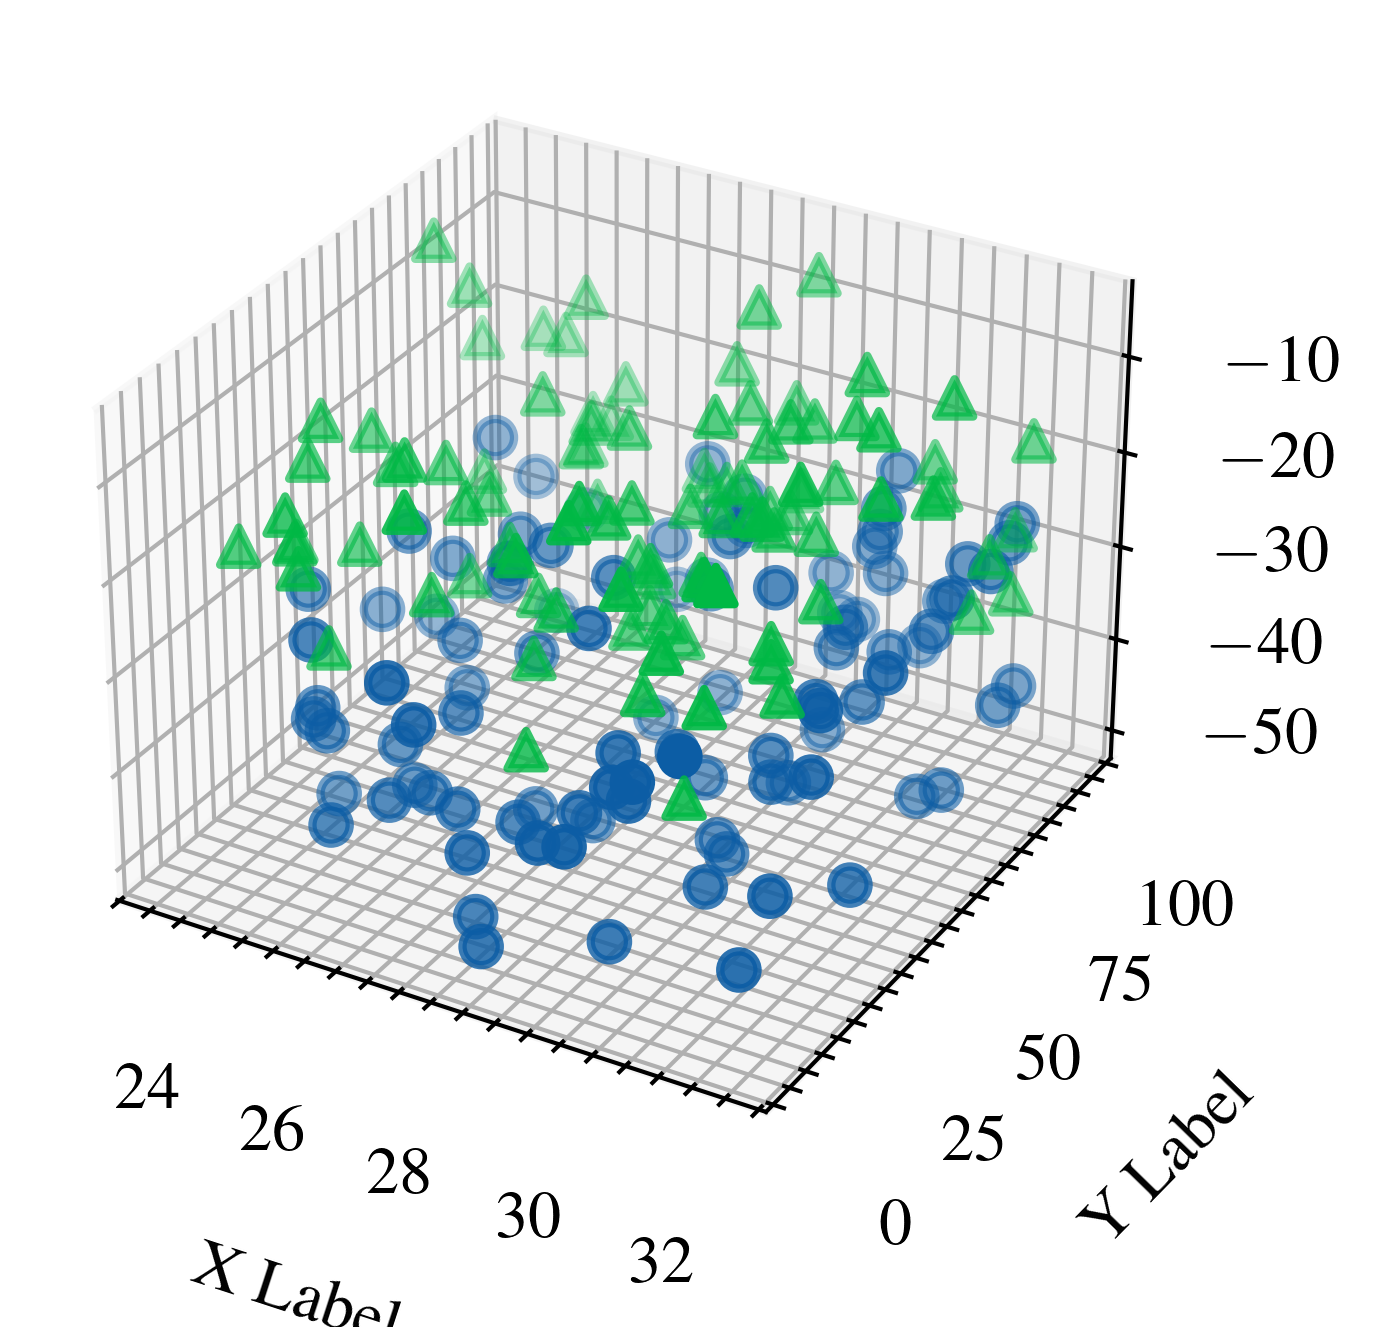

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import scienceplots
plt.style.use(['science', "ieee", 'std-colors'])

# Fixing random state for reproducibility
np.random.seed(19680801)


def randrange(n, vmin, vmax):
    """
    Helper function to make an array of random numbers having shape (n, )
    with each number distributed Uniform(vmin, vmax).
    """
    return (vmax - vmin)*np.random.rand(n) + vmin

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

n = 100

# For each set of style and range settings, plot n random points in the box
# defined by x in [23, 32], y in [0, 100], z in [zlow, zhigh].
for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = randrange(n, 23, 32)
    ys = randrange(n, 0, 100)
    zs = randrange(n, zlow, zhigh)
    ax.scatter(xs, ys, zs, marker=m)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

plt.show()

In [1]:
# test simulation time
import sire
import numpy as np
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
startK = 2e3
endK = 1e40
startD = 0
endD = 1e6
num_points = 100
k = np.geomspace(startK, endK, num_points)
d = np.linspace(startD, endD, num_points)
K, D = np.meshgrid(k, d)
contactSolveTime = np.zeros((num_points, num_points))
# parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 10
dt = 0.001
ctrlt = 100
# timeCostResult = np.zeros([len(parameters), n])

for i in range(K.shape[0]):      # 遍历行
    for j in range(K.shape[1]):  # 遍历列
      # timeCost = 0
      sire.fromXmlFile(cs, abspath(os.getcwd()) + "/profile_contact.xml")
      cs.init()
      simulator = sire.simulationLoop(cs)
      pe = cs.physicsEngine()
      k_val = K[i, j]
      d_val = D[i, j]
      contactPropStr = f"{{k:{k_val},d:{d_val},cof:0,threshold_velocity:1e-4}}"
      # print(contactPropStr)
      pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
      isCtrl = simulator.integrate()
      # start = time.perf_counter()
      simulator.handleContact()
      # end = time.perf_counter()
      # elapsed = end - start
      # timeCostResult[i][j] = elapsed  
      contact_solver_result = simulator.recordsContactCptInfo()
      contactSolveTime[i, j] = contact_solver_result["minTime"][0]
contactSolveTime[contactSolveTime == -1] = 1e-20
# print(contactSolveTime)

In [2]:
# 在绘图前添加以下代码调整显示
import plotly.graph_objects as go
import numpy as np

# 确保数据中没有零或负值（对数坐标需要）
contactSolveTime_processed = np.array(contactSolveTime)
contactSolveTime_processed[contactSolveTime_processed <= 0] = 1e-10

# 创建图形
fig = go.Figure(
    data=[go.Surface(
        z=contactSolveTime_processed, 
        x=K, 
        y=D, 
        colorscale="Reds", 
        opacity=0.8,  # 增加不透明度
        showscale=True  # 确保颜色条显示
    )]
)

# 调整布局和坐标轴
fig.update_layout(
    scene=dict(
        xaxis=dict(
            type='log',
            title='k',
            exponentformat='power',  # 更改科学计数法格式
            showexponent='all'
        ),
        yaxis=dict(
            title='d',
            exponentformat='power',  # 更改科学计数法格式
            showexponent='all'
        ),
        zaxis=dict(
            type='log',
            title='Solve Time',
            exponentformat='power',  # 更改科学计数法格式
            showexponent='all'
        ),
        # 调整相机视角，使图形更大
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        # 调整纵横比
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.7)
    ),
    # 调整图形大小
    width=800,
    height=600,
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [43]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# 准备数据
x_flat = K.flatten()
y_flat = D.flatten()
z_flat = contactSolveTime.flatten()

valid_mask = z_flat > 1e-20
x_valid = x_flat[valid_mask]
y_valid = y_flat[valid_mask]
z_valid = z_flat[valid_mask]

# 创建带控件的3D散点图
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=x_valid,
    y=y_valid,
    z=z_valid,
    mode='markers',
    marker=dict(
        size=4,
        color=z_valid,
        # colorscale='Hot',
        opacity=0.7,
        # colorbar=dict(title="Solve Time", x=1.0)
    ),
    name='Contact Solve Time'
))

# 添加滑块控制透明度
steps = []
for i, opacity in enumerate([0.3, 0.5, 0.7, 1.0]):
    step = dict(
        method='restyle',
        args=['marker.opacity', opacity],
        label=f'Opacity: {opacity}'
    )
    steps.append(step)

sliders = [dict(
    active=2,
    currentvalue={"prefix": "Marker Opacity: "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    scene=dict(
        xaxis=dict(
            type='log',
            title='k',
            exponentformat='power',  # 更改科学计数法格式
            showexponent='all'
        ),
        yaxis=dict(
            title='d',
            exponentformat='power',  # 更改科学计数法格式
            showexponent='all'
        ),
        zaxis=dict(
            type='log',
            title='Solve Time',
            exponentformat='power',  # 更改科学计数法格式
            showexponent='all'
        ),
        # 调整相机视角，使图形更大
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        # 调整纵横比
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.7)
    ),
    # 调整图形大小
    sliders=sliders,
    width=900,
    height=700,
    # margin=dict(l=0, r=0, b=0, t=0)
)


fig.show()